# 银行信用风险评估模型
## 1. 模型功能介绍
模型需要完成数据探索、数据清洗、数据预处理、模型预测以及输出实验结果报告的功能。
## 2. 具体各个功能的设计要求（预设）
### 2.1 数据探索
* 核心任务：
    * 统计分析：计算各变量的均值、中位数、方差、缺失比例等基本统计量，对数据分布有一个宏观的认识。
    * 可视化分析：利用直方图、箱线图、散点图等工具，直观地展示单个变量的分布情况以及变量之间的相互关系。
    * 相关性分析：分析不同特征与贷款违约（或信用评分）之间的相关性，初步筛选出可能对预测结果有重要影响的变量
* 最终产出
    * 描述数据（或客户群体特征）
### 2.2 数据清洗与再探索
* 对数据的缺失值进行处理：
    * 剔除：提出极小比例的缺失值、空白值、重复值
    * 插值：如果存在较大比例的缺失值，使用特定的插值方法进行插值
### 2.3 数据预处理（特征指标构建）
* 编码
    * 机器学习模型往往只能处理数值型数据，因此需要对一些类别数据进行编码（如性别、职业、婚姻状况等）
* 特征构造
    * 构造一些基于业务理解的特征变量，比如通过总负债-月收入，构造出还款能力指标。来辅助预测。
### 2.4 模型预测
* 一般线性回归模型方法
* 逻辑回归模型
### 2.5 实验结果报告输出
将所有结果输出总结，结合业务场景进行报告分析。

# 代码实现

## 1. 数据探索
### 目标数据表的基本结构
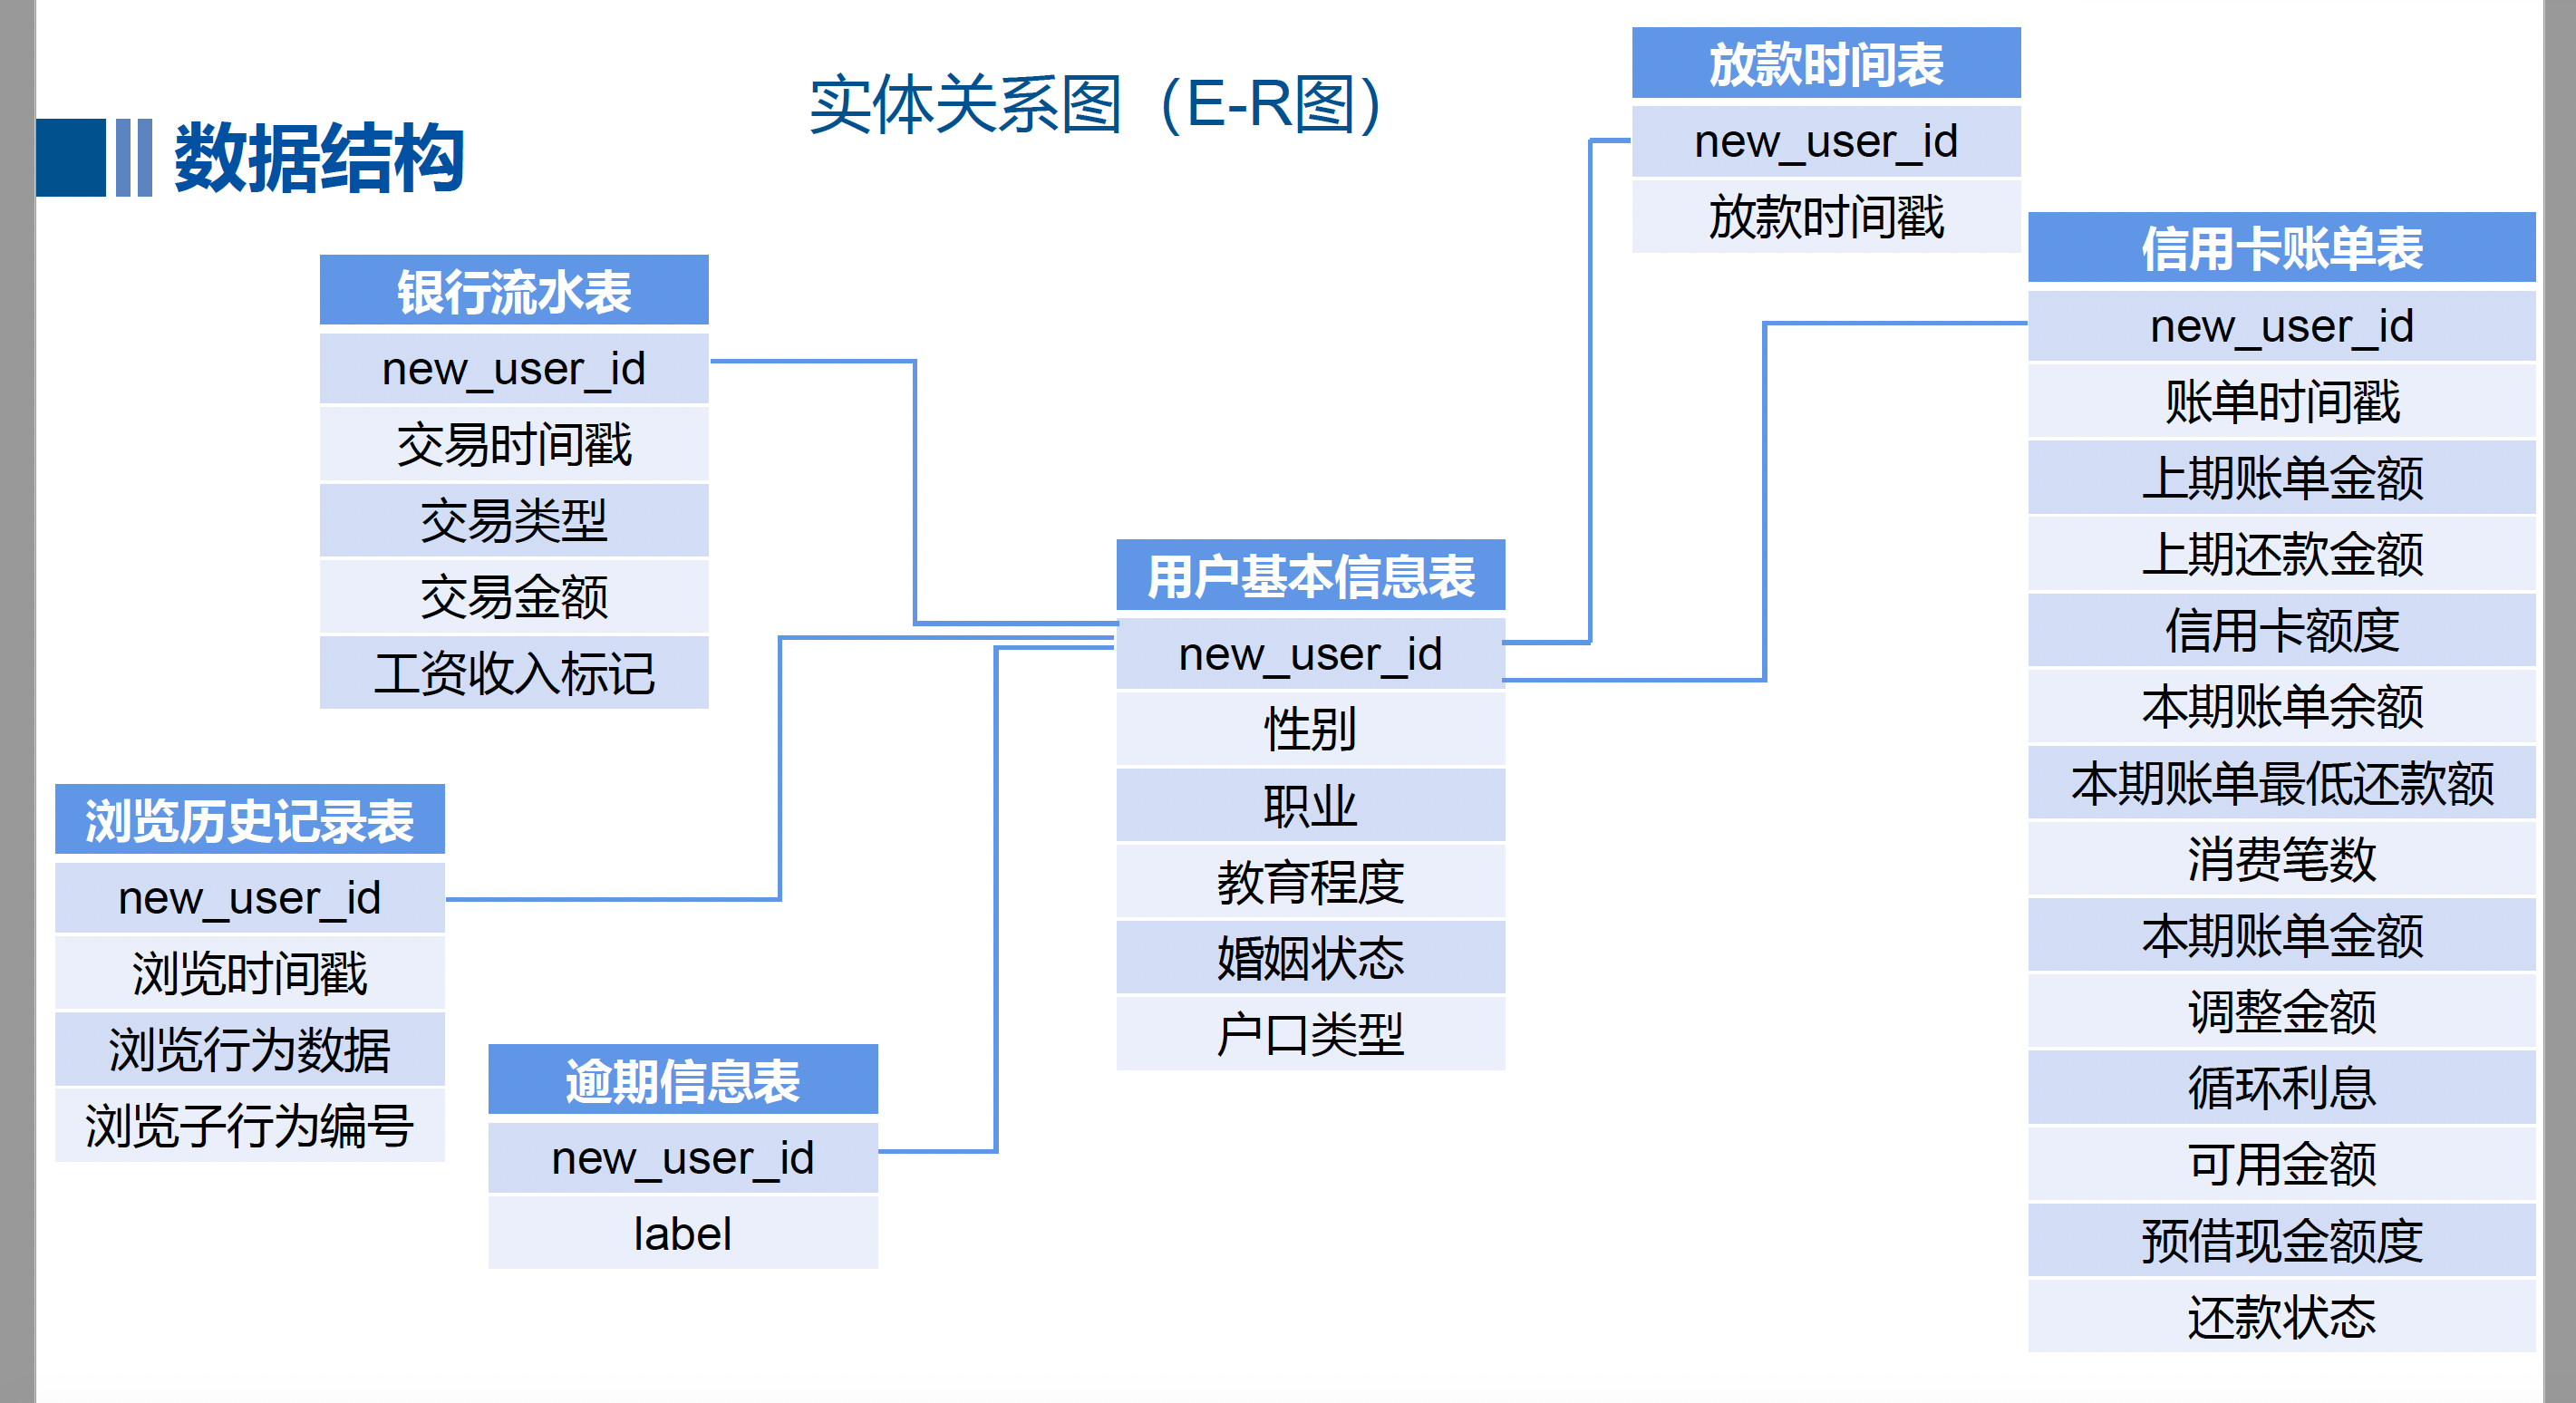

### 描述性统计
* 输出汇总查看每张表的信息：
    * 1. 查看每一列的数据类型
    * 2. 查看缺失值

In [16]:
import pandas as pd
import os
from io import StringIO
# --- 分析与预览函数 ---
def analyze_and_preview_dataframe(table_name, df):
    
    print(f" 分析报告: {table_name} ".center(60, "="))
    # --- 1. 数据预览 ---
    print(df.head(10).to_string())
    # --- 2. 数据结构与类型 ---
    print("\n[+] 2. 数据结构与列类型")
    print("-" * 60)
    buffer = StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    print('\n'.join(info_str.split('\n')[1:-2]))
    print("-" * 60)
    # --- 3. 缺失值统计分析 ---
    print("\n[+] 3. 缺失值统计分析")
    print("-" * 60)
    missing_counts = df.isnull().sum()
    missing_values = missing_counts[missing_counts > 0]

    if missing_values.empty:
        print("状态: 该数据表无缺失值。")
    else:
        missing_percentage = (missing_values / len(df)) * 100
        missing_df = pd.DataFrame({
            '字段名': missing_values.index,
            '缺失数量': missing_values.values,
            '缺失比例 (%)': missing_percentage.values.round(2)
        })
        print("状态: 检测到以下字段存在缺失值：\n")
        print(missing_df.to_string(index=False))
        
    print("-" * 60)
    print("\n\n")

# --- 主要分析流程 --
# 1. 设定您的CSV文件所在的文件夹路径
data_directory = 'OrigionalData' 

# 2. 定义表名和对应的文件名
csv_files_map = {
    "用户基本信息表": "userinfo.csv",
    "银行流水表": "bank.csv",
    "信用卡账单表": "bill.csv",
    "逾期信息表": "overdue.csv"
}

# 3. 遍历字典，读取并分析每个CSV文件
for table_name, file_name in csv_files_map.items():
    file_path = os.path.join(data_directory, file_name)
    
    try:
        # **已删除日期解析逻辑**
        # 直接读取CSV文件，让pandas自动推断数据类型
        df = pd.read_csv(file_path)
        
        # 调用分析函数
        analyze_and_preview_dataframe(table_name, df)
        
    except FileNotFoundError:
        print(f"错误: 文件未找到，请检查路径: {file_path}\n")

====================== 分析报告: 用户基本信息表 =======================
                        new_user_id  性别    职业   教育程度 婚姻状态  户口类型
0  7259fe272934e0dc348092c37544a445   女    公职  本科及以上   未婚  集体户口
1  0c87f6b1f7e0350a35841ba34df9d26a   男    公职  本科及以上   离异  集体户口
2  74c53a62f15cc039864aefc41170f81b   男    公职     大专   离异  家庭户口
3  211f56f356fa6ecc6334bb73e52c7b16   男    企业     高中   离异  农业户口
4  07b0d9ac7924424894141b2fecfa0ee0   男    公职  本科及以上   已婚  集体户口
5  eae1eb085759f537f9ebfff6756a7449   女  事业单位     大专   未婚  家庭户口
6  f252acaac66355ee480542cb658036f9   男    公职  本科及以上   未婚  集体户口
7  a513c20cfd5b960125524c976fae6a7b   男    公职  本科及以上   未婚  家庭户口
8  fa8dada7730dad624a34418167f10a06  未知    公职     高中   离异  农业户口
9  6f6e0d7f5d4d1f037499f6bc2fceffae   女  事业单位  本科及以上   未婚  农业户口

[+] 2. 数据结构与列类型
------------------------------------------------------------
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   n

* 输出的结果解读：
    * 用户信息表（userinfo）：
        1. 职业信息存在2个缺失值，婚姻状态存在1个缺失值,性别存在一个`未知`类别
        2. 数据类型均为object类型，说明为字符串类型
    * 银行流水表(bank)：
        1. 各个字段数据均无缺失值
        2. 数据类型为int和float类型（new_user_id和交易时间为object类型除外）
    * 信用卡账单表（bill）：
        1. 各个字段数据均无缺失值
        2. 数据类型为int和float类型（new_user_id和账单时间为object类型除外）
    * 信息逾期表（overdue）：
        1. 无缺失值
        2. 存在`unnamed`列
        3. 数据类型为int和float类型（new_user_id为object类型）


## 2. 数据清洗与再探索
剔除缺失值、`unnamed`列、性别为`未知`的数据


In [32]:
# 该板块的环境配置
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
import time

# 解决中文显示问题
# 设置全局字体
plt.rcParams["font.family"] = ["Arial Unicode MS"] # Mac系统
plt.rcParams['axes.unicode_minus']=False # 解决负号'-'显示为

# --- 数据加载 ---
data_directory = 'OrigionalData' 
df_user_info = pd.read_csv(os.path.join(data_directory, 'userinfo.csv'))
df_bank = pd.read_csv(os.path.join(data_directory, 'bank.csv'))
df_bill = pd.read_csv(os.path.join(data_directory, 'bill.csv'))
df_overdue = pd.read_csv(os.path.join(data_directory, 'overdue.csv'))

### 2.1 数据清洗

In [34]:

# 清洗 逾期信息表
print(f"逾期信息表（overdue） (清洗前): {df_overdue.shape}")
if 'Unnamed: 0' in df_overdue.columns:
    df_overdue.drop('Unnamed: 0', axis=1, inplace=True)
print(f"逾期信息表（overdue） (清洗后): {df_overdue.shape}")

# 清洗 用户基本信息表
print(f"\n用户基本信息表（userinfo） (清洗前): {df_user_info.shape}")
# 剔除性别为'未知'的行
remove_cols = ['性别', '教育程度', '婚姻状态', '户口类型']

# 删除这些列中包含 '未知' 的行
df_user_info_cleaned = df_user_info[
    ~df_user_info[remove_cols].isin(['未知']).any(axis=1)
].copy()
# 剔除包含任何缺失值的行
df_user_info_cleaned.dropna(inplace=True)
print(f"用户基本信息表（userinfo） (清洗后): {df_user_info_cleaned.shape}")





逾期信息表（overdue） (清洗前): (10000, 3)
逾期信息表（overdue） (清洗后): (10000, 3)

用户基本信息表（userinfo） (清洗前): (10000, 6)
用户基本信息表（userinfo） (清洗后): (9715, 6)


### 2.2 可视化绘图（已清洗数据再探索）
对所有字段进行`暴力匹配绘图`,方便后续进行数据分，捕捉有特点的数据。对有特点的数据进行单独的`聚焦`分析。

In [39]:
import pandas as pd
import numpy as np
import os

# 1. 找出所有分类列
all_object_cols = df_user_info_cleaned.select_dtypes(include=["object"]).columns
categorical_cols = [c for c in all_object_cols if c != "new_user_id"]

# 2. 执行独热编码
df_user_info_encoded = pd.get_dummies(df_user_info_cleaned, columns=categorical_cols, prefix=categorical_cols)

# 3. 数值部分（去掉 user_id）
X = df_user_info_encoded.drop(columns=["new_user_id"], errors="ignore")
col_list = X.columns.tolist()

# 4. 为每个分类列与其取值生成 one-hot 向量
mapping_rows = []

for col in categorical_cols:
    # 找属于这个变量的 one-hot 列
    ohe_cols = [c for c in col_list if c.startswith(col + "_")]
    ohe_cols_sorted = sorted(ohe_cols)   # 保持固定顺序
    
    # 为每个独热编码列生成完整向量
    for oc in ohe_cols_sorted:
        original_value = oc.replace(col + "_", "")
        
        # 构造一个全 0 向量
        vector = [0] * len(col_list)
        
        # 找到该 one-hot 列在 X 的向量维度中的位置
        idx = col_list.index(oc)
        vector[idx] = 1  # 设置 1
        
        mapping_rows.append([
            col,
            original_value,
            oc,
            vector
        ])

# 5. 输出 DataFrame
df_ohe_vector_map = pd.DataFrame(
    mapping_rows,
    columns=["原始列名", "原始取值", "独热编码列名", "对应向量"]
)

print("\n=== 每个类型对应的独热向量 ===")
print(df_ohe_vector_map)

# 将每个类型对应的独热向量存入 CSV 文件
output_file = "OutputData_COB/ohe_vector_mapping.csv"
os.makedirs(os.path.dirname(output_file), exist_ok=True)
df_ohe_vector_map.to_csv(output_file, index=False, encoding="utf-8-sig")
print(f"\n独热编码向量对应表已成功写入: {output_file}")


=== 每个类型对应的独热向量 ===
    原始列名   原始取值      独热编码列名                                               对应向量
0     性别      女        性别_女  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1     性别      男        性别_男  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2     职业   事业单位     职业_事业单位  [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3     职业     企业       职业_企业  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4     职业     公职       职业_公职  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
5     职业     无业       职业_无业  [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
6   教育程度  初中及以下  教育程度_初中及以下  [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...
7   教育程度     大专     教育程度_大专  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...
8   教育程度  本科及以上  教育程度_本科及以上  [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...
9   教育程度     高中     教育程度_高中  [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...
10  婚姻状态     丧偶     婚姻状态_丧偶  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...
11  婚姻状态   其他情况   婚姻状态_其他情况  [0


######################################################################
# 用户基本信息表                                                            #
######################################################################
| 说明: ...
| 维度: 9715 行 x 6 列
######################################################################


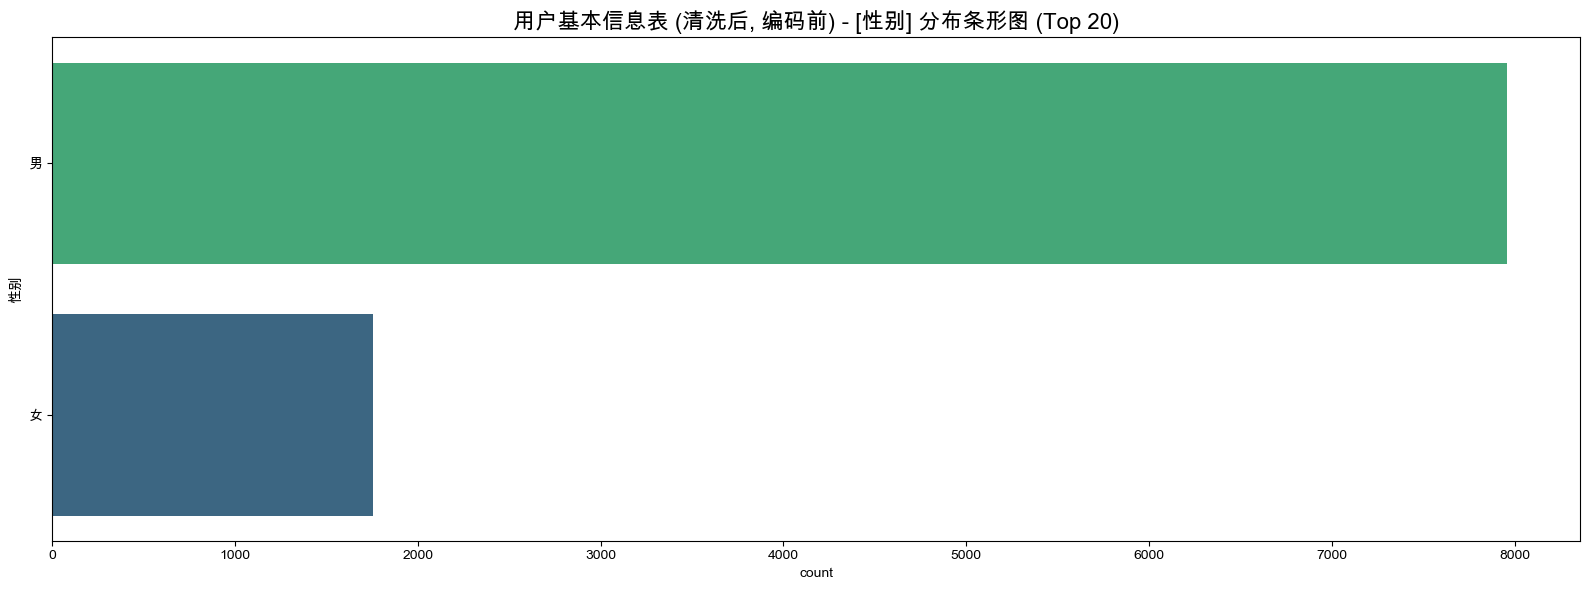


------------------------- [📊 自动解读: 性别] -------------------------
- **主要发现**: 该字段共有 2 个不同类别。
- **主导类别**: '男' 是最常见的类别，出现了 7959 次，占比 81.92%。
--------------------------------------------------------------------------


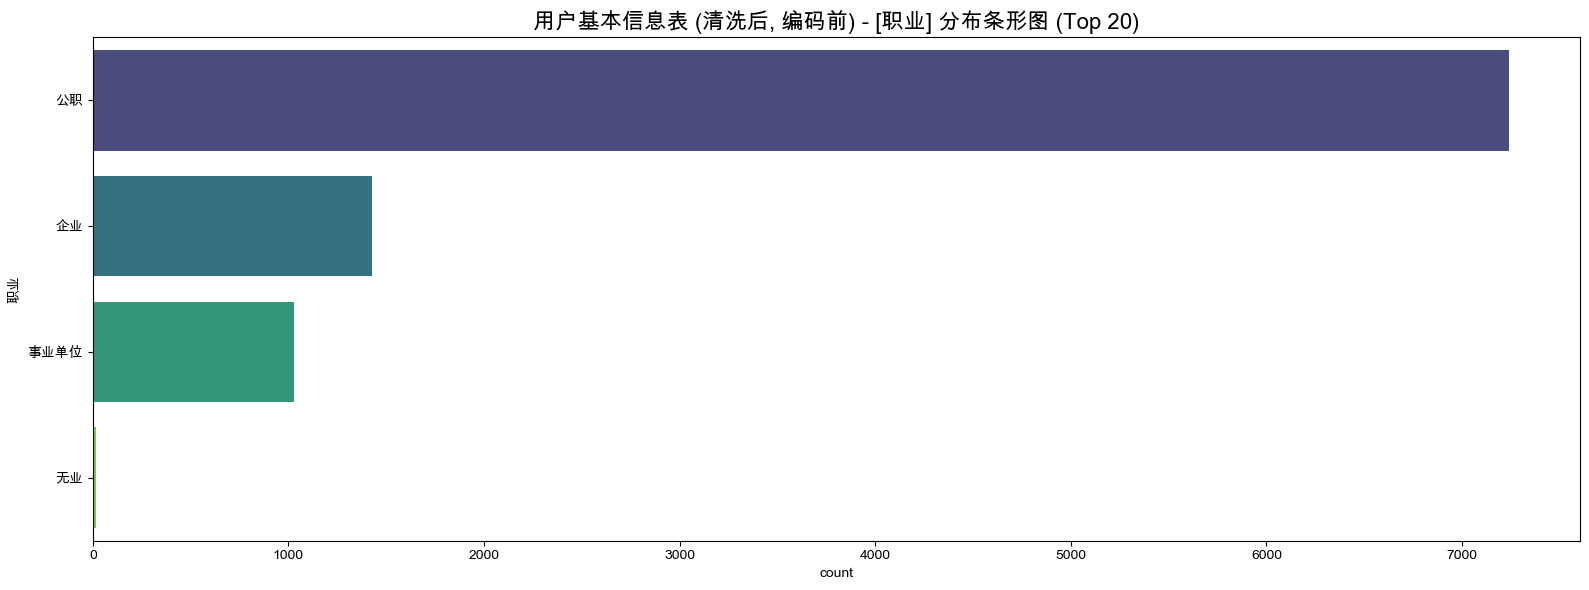


------------------------- [📊 自动解读: 职业] -------------------------
- **主要发现**: 该字段共有 4 个不同类别。
- **主导类别**: '公职' 是最常见的类别，出现了 7241 次，占比 74.53%。
--------------------------------------------------------------------------


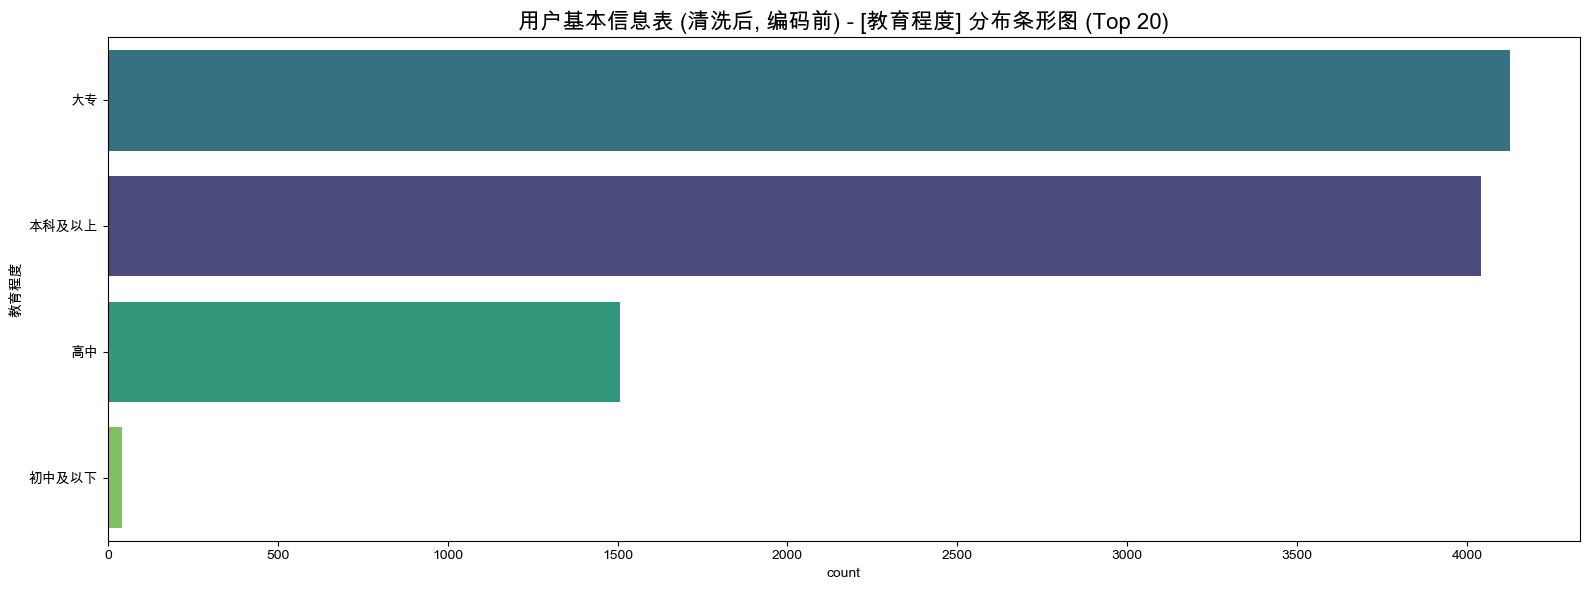


------------------------- [📊 自动解读: 教育程度] -------------------------
- **主要发现**: 该字段共有 4 个不同类别。
- **主导类别**: '大专' 是最常见的类别，出现了 4126 次，占比 42.47%。
----------------------------------------------------------------------------


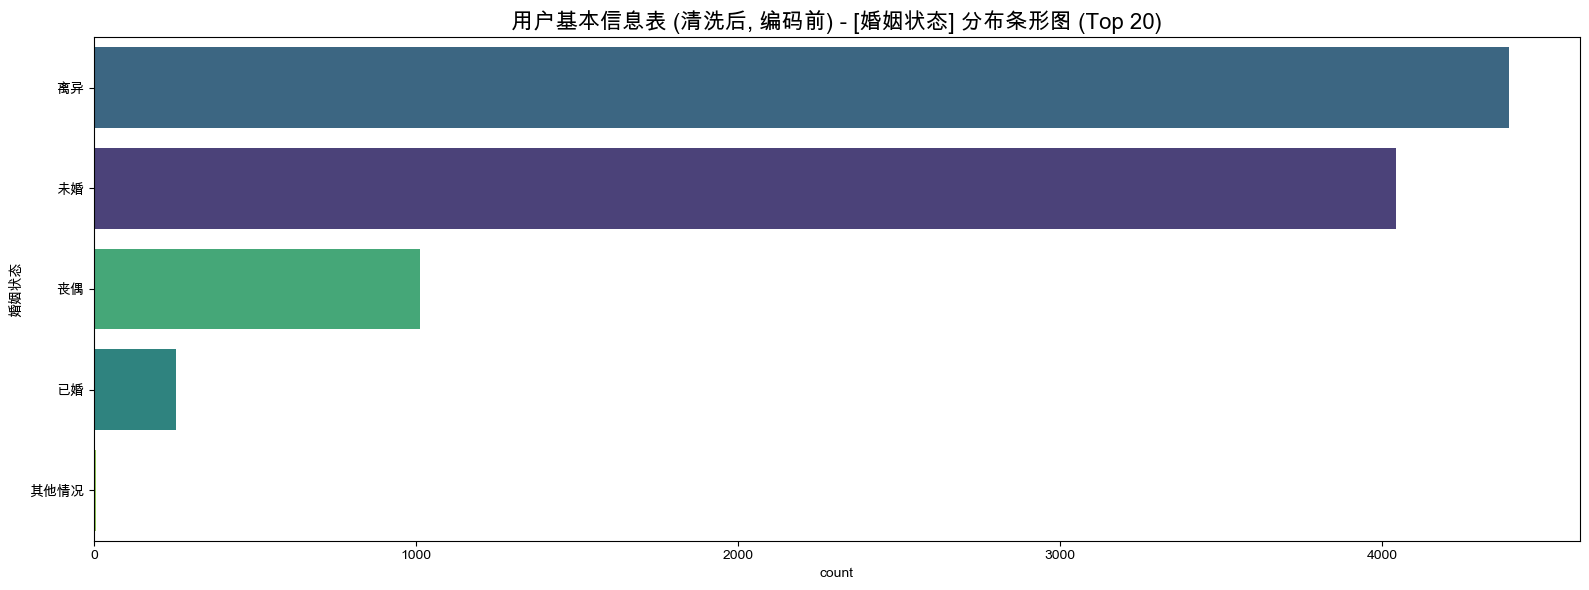


------------------------- [📊 自动解读: 婚姻状态] -------------------------
- **主要发现**: 该字段共有 5 个不同类别。
- **主导类别**: '离异' 是最常见的类别，出现了 4395 次，占比 45.24%。
----------------------------------------------------------------------------


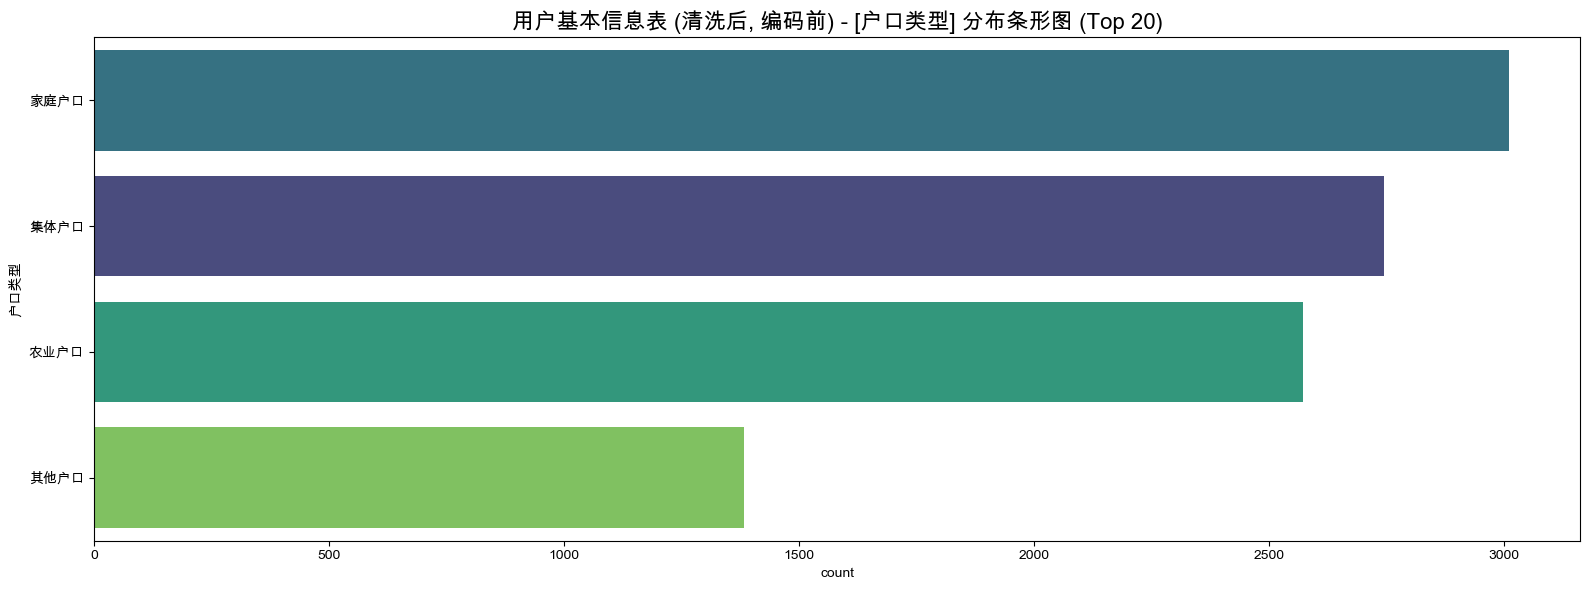


------------------------- [📊 自动解读: 户口类型] -------------------------
- **主要发现**: 该字段共有 4 个不同类别。
- **主导类别**: '家庭户口' 是最常见的类别，出现了 3012 次，占比 31.00%。
----------------------------------------------------------------------------

######################################################################
# 银行流水表                                                              #
######################################################################
| 说明: ...
| 维度: 1068424 行 x 12 列
######################################################################
| 提示: 数据量较大，将使用 1000000 行的随机样本进行绘图...


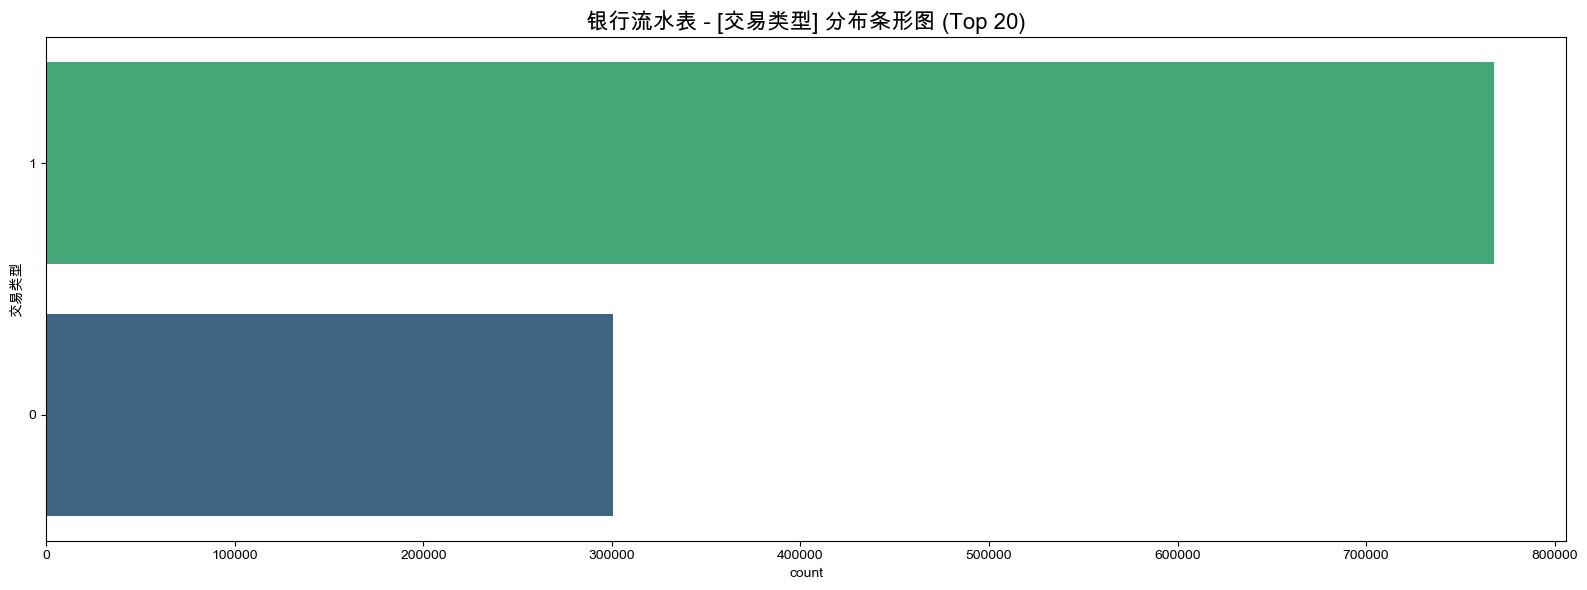


------------------------- [📊 自动解读: 交易类型] -------------------------
- **主要发现**: 该字段共有 2 个不同类别。
- **主导类别**: '1' 是最常见的类别，出现了 767791 次，占比 71.86%。
----------------------------------------------------------------------------


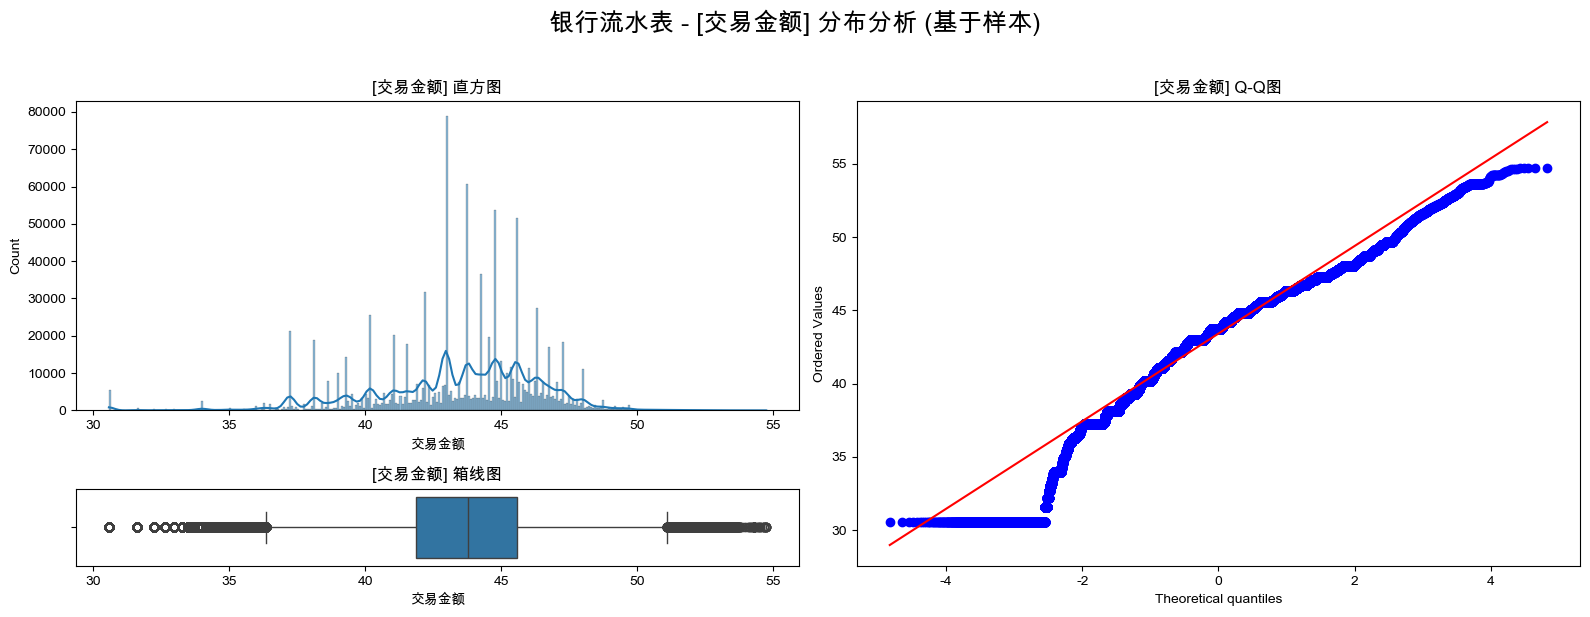


------------------------- [📊 自动解读: 交易金额] -------------------------
- **中心趋势**: 均值为 43.42，中位数为 43.76。
----------------------------------------------------------------------------


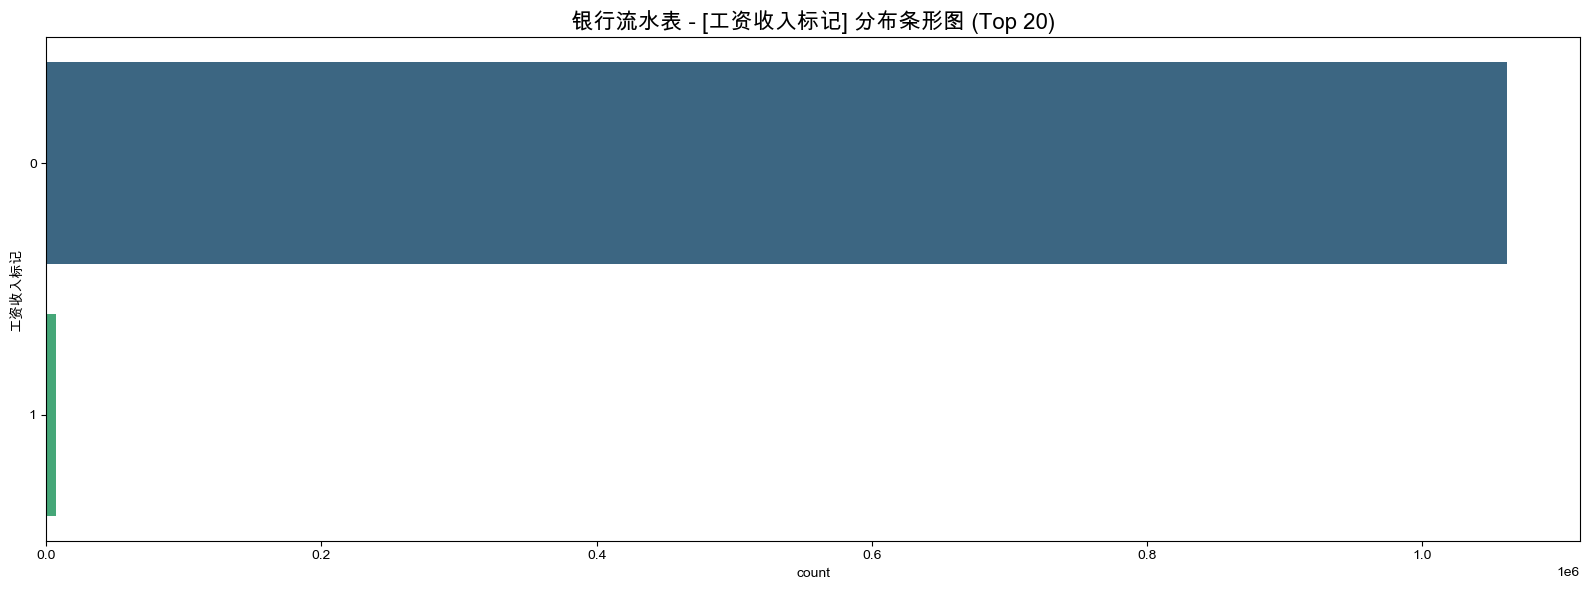


------------------------- [📊 自动解读: 工资收入标记] -------------------------
- **主要发现**: 该字段共有 2 个不同类别。
- **主导类别**: '0' 是最常见的类别，出现了 1061734 次，占比 99.37%。
------------------------------------------------------------------------------

######################################################################
# 信用卡账单表                                                             #
######################################################################
| 说明: ...
| 维度: 429441 行 x 22 列
######################################################################


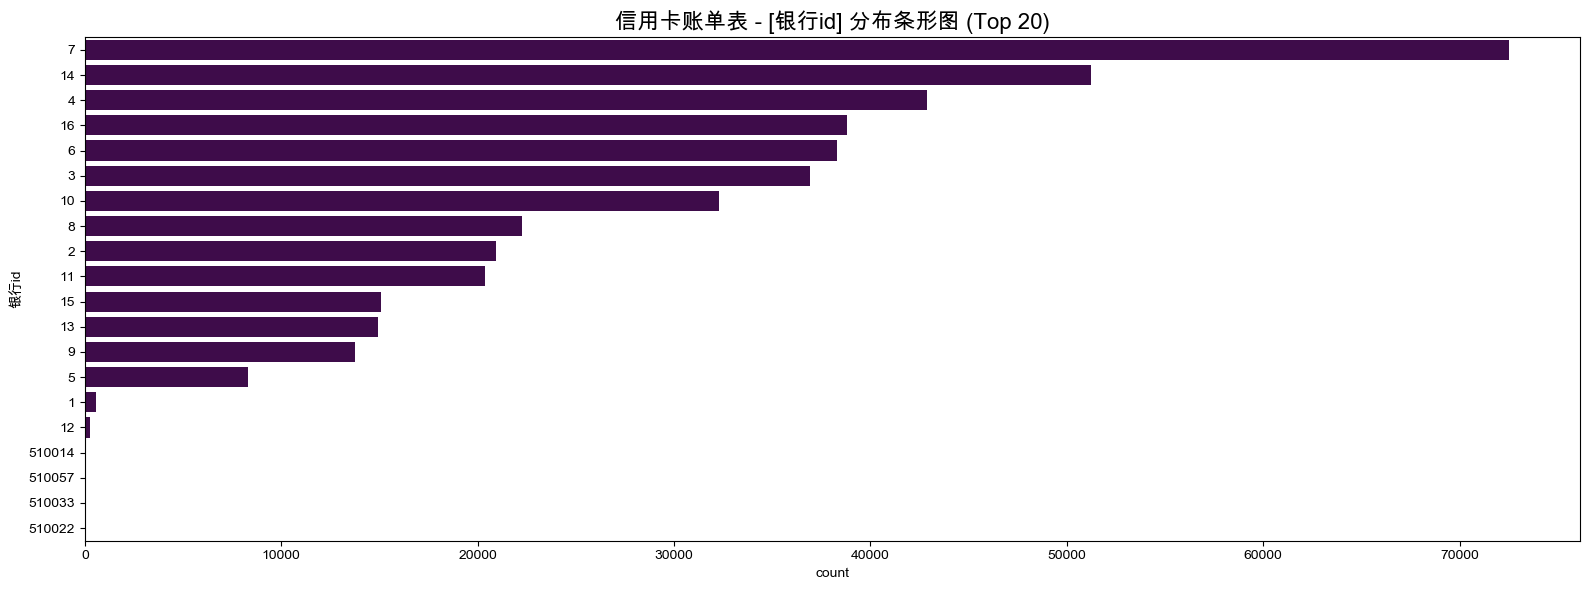


------------------------- [📊 自动解读: 银行id] -------------------------
- **主要发现**: 该字段共有 20 个不同类别。
- **主导类别**: '7' 是最常见的类别，出现了 72509 次，占比 16.88%。
----------------------------------------------------------------------------


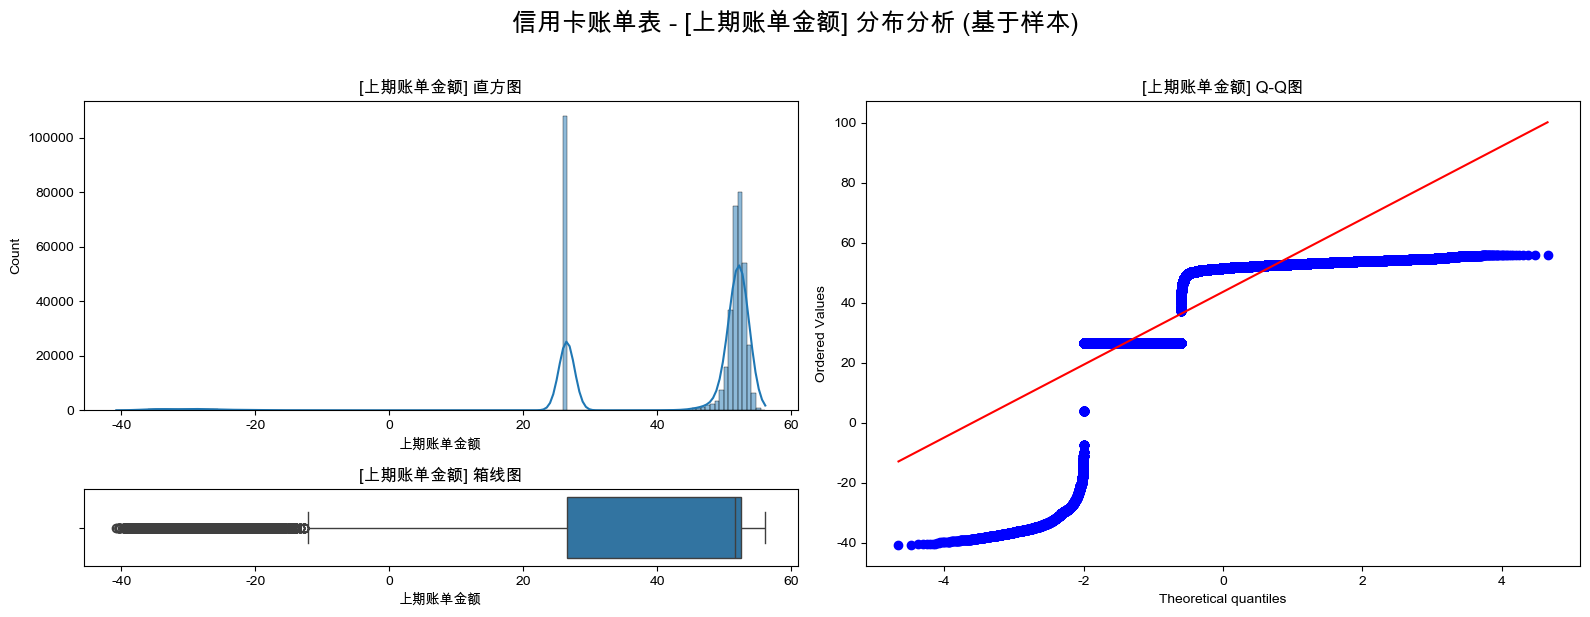


------------------------- [📊 自动解读: 上期账单金额] -------------------------
- **中心趋势**: 均值为 43.67，中位数为 51.53。
------------------------------------------------------------------------------


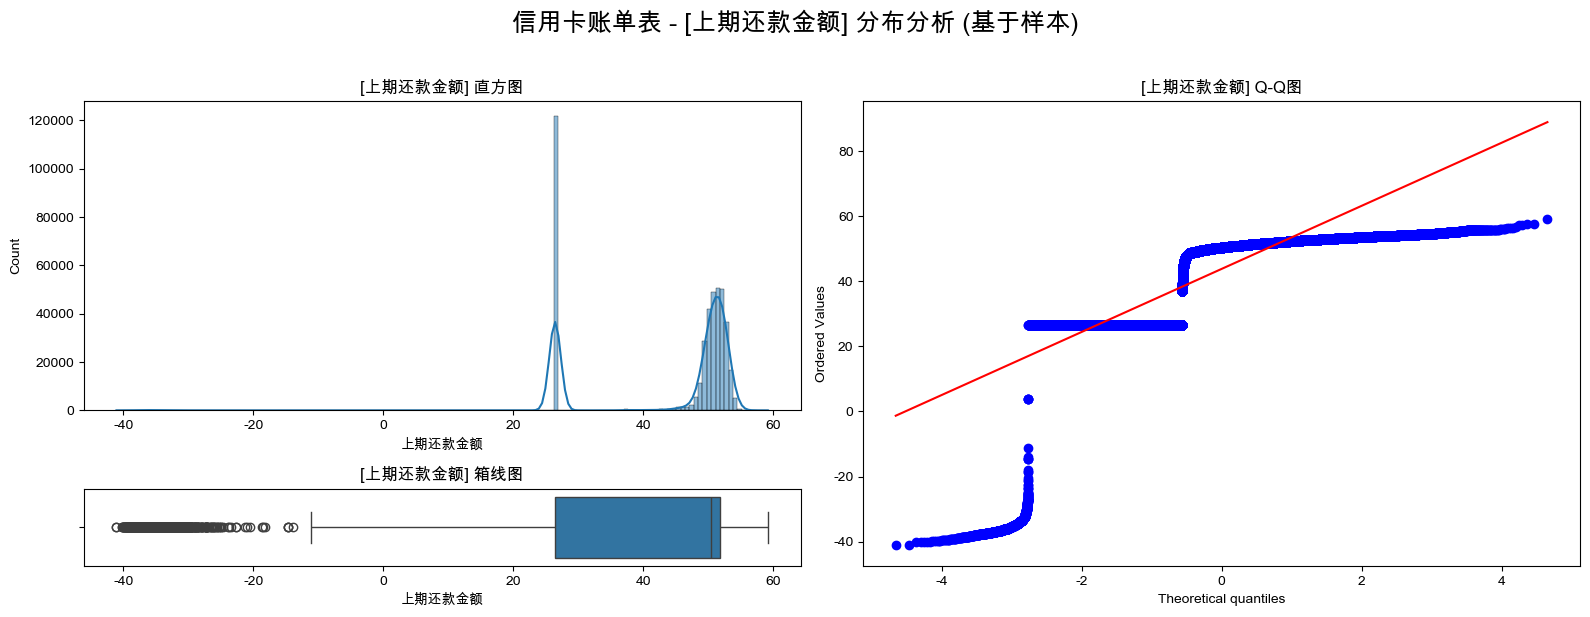


------------------------- [📊 自动解读: 上期还款金额] -------------------------
- **中心趋势**: 均值为 43.85，中位数为 50.41。
------------------------------------------------------------------------------


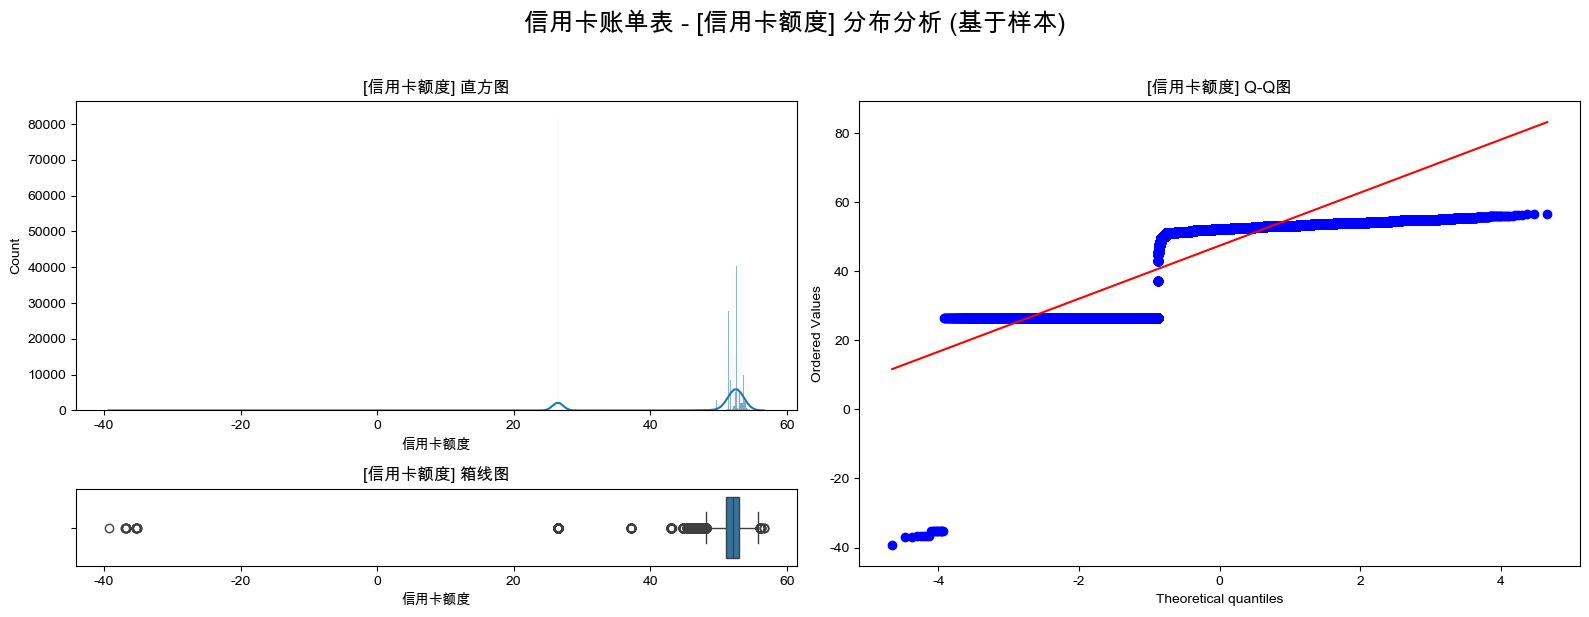


------------------------- [📊 自动解读: 信用卡额度] -------------------------
- **中心趋势**: 均值为 47.43，中位数为 52.11。
-----------------------------------------------------------------------------


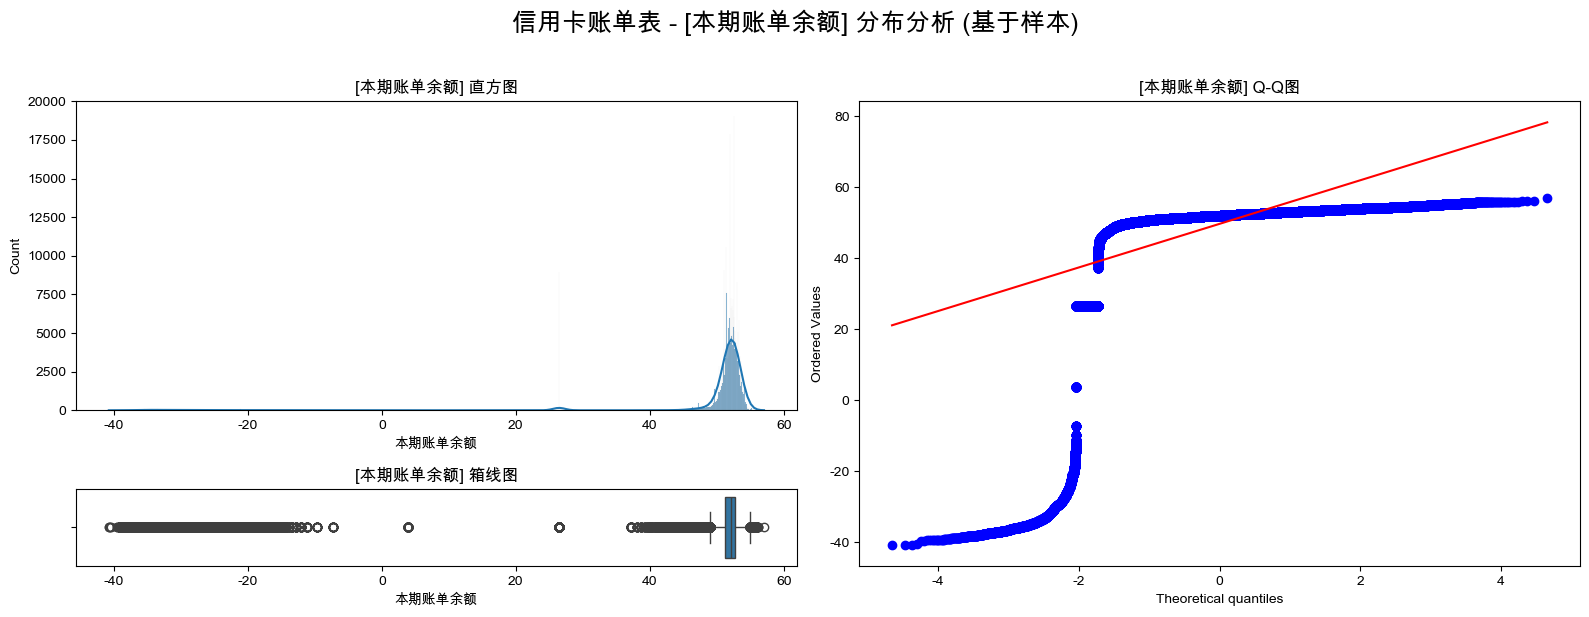


------------------------- [📊 自动解读: 本期账单余额] -------------------------
- **中心趋势**: 均值为 49.75，中位数为 52.06。
------------------------------------------------------------------------------


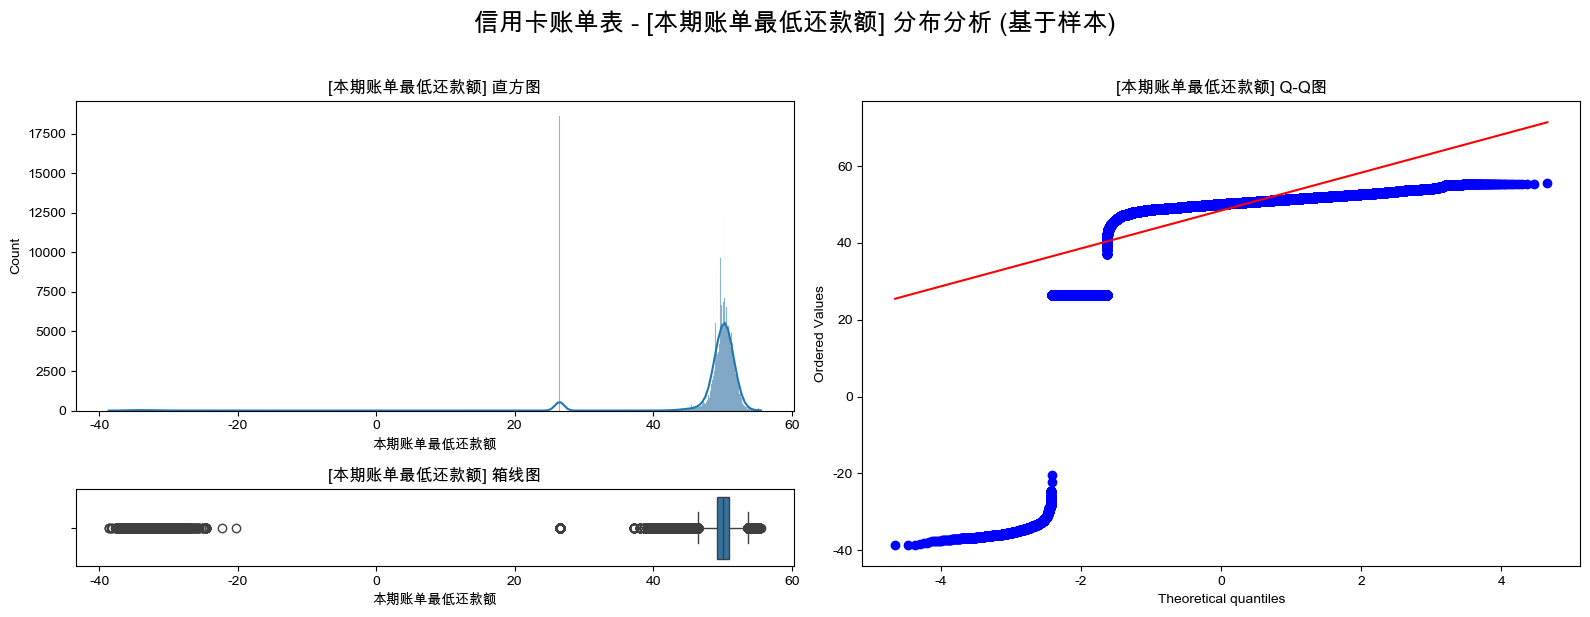


------------------------- [📊 自动解读: 本期账单最低还款额] -------------------------
- **中心趋势**: 均值为 48.43，中位数为 50.13。
---------------------------------------------------------------------------------


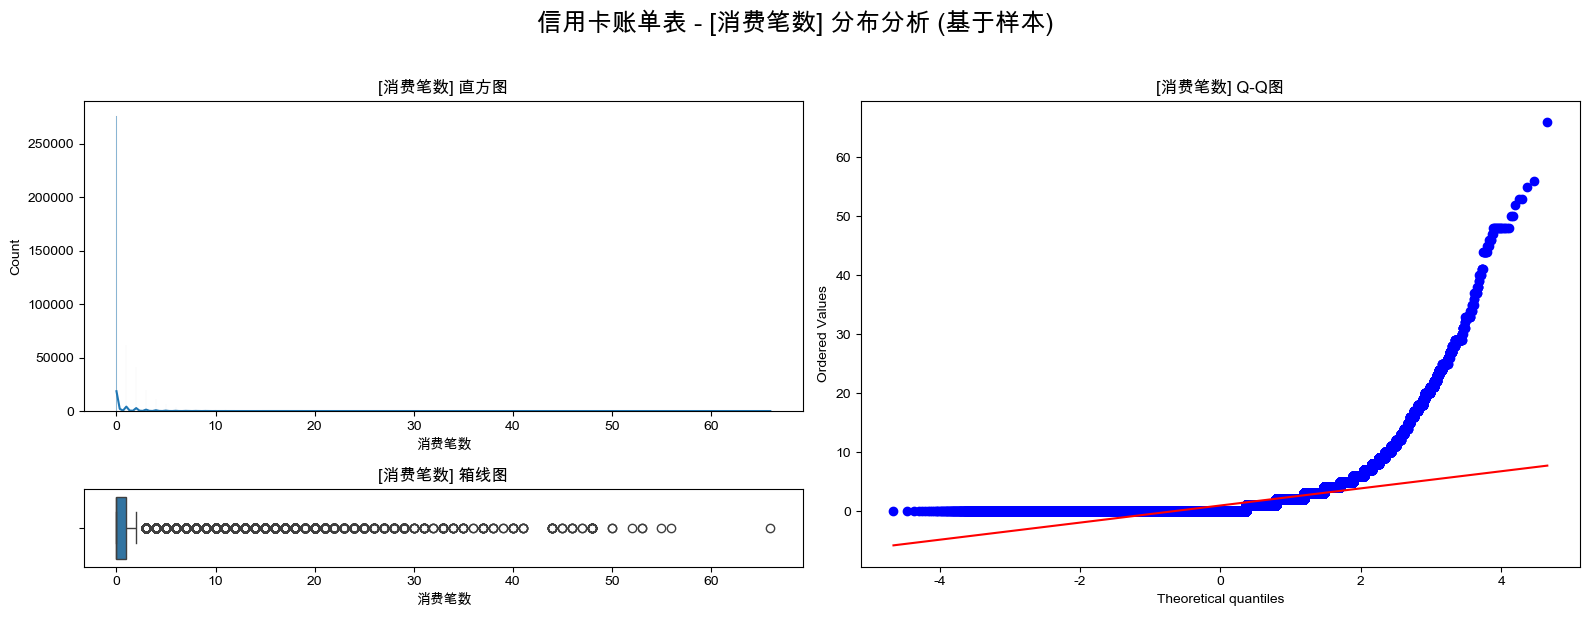


------------------------- [📊 自动解读: 消费笔数] -------------------------
- **中心趋势**: 均值为 0.94，中位数为 0.00。
----------------------------------------------------------------------------


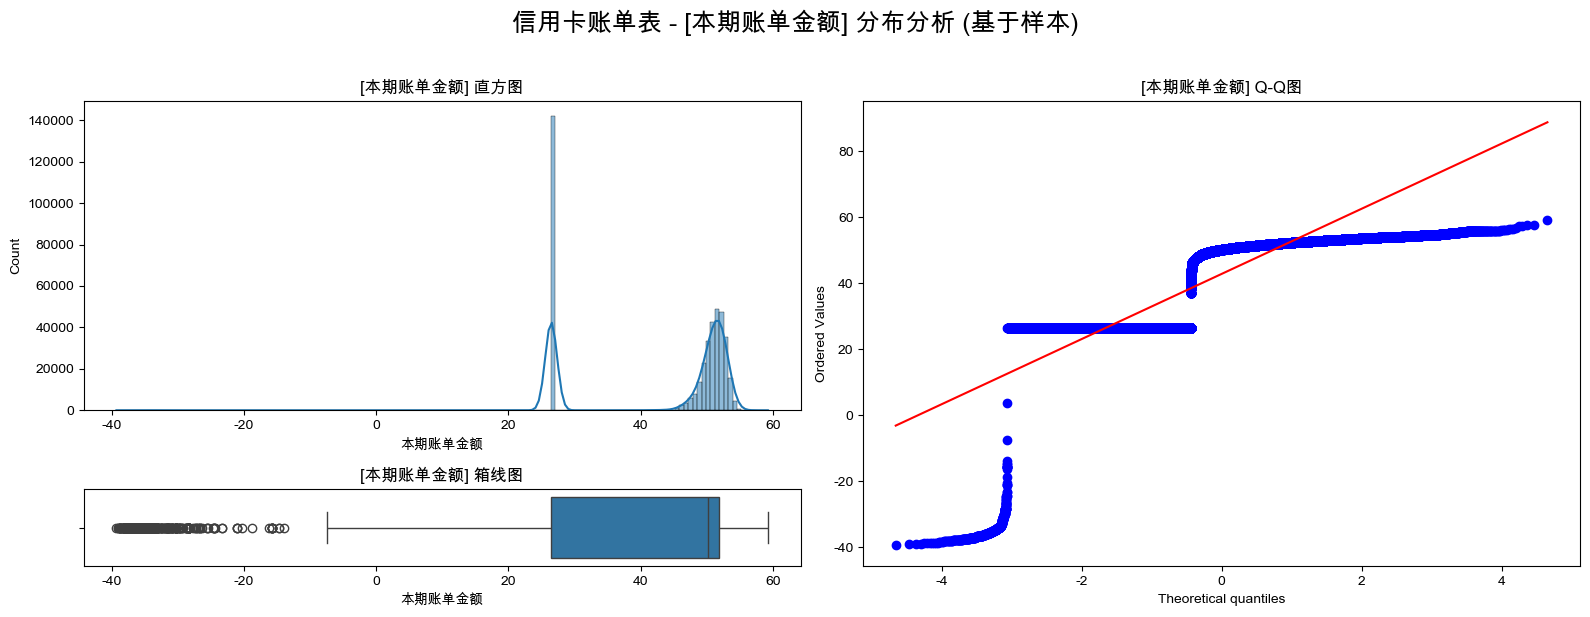


------------------------- [📊 自动解读: 本期账单金额] -------------------------
- **中心趋势**: 均值为 42.85，中位数为 50.20。
------------------------------------------------------------------------------


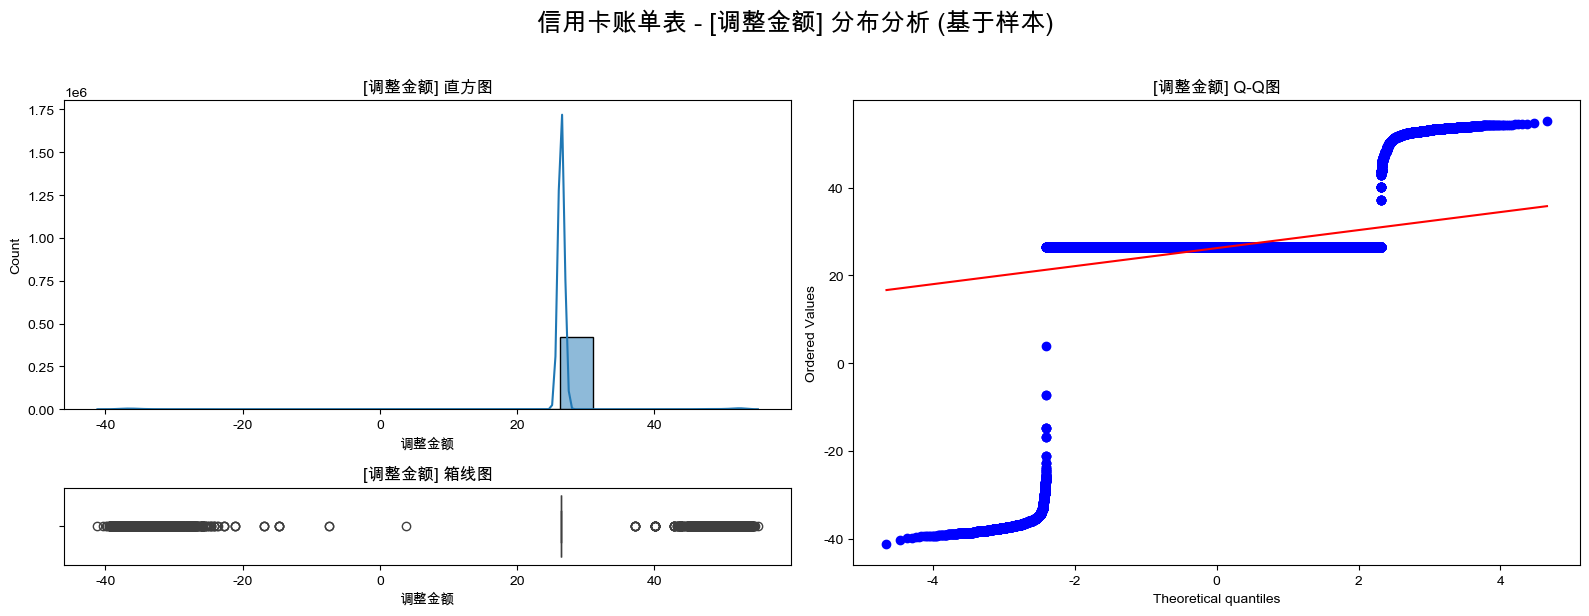


------------------------- [📊 自动解读: 调整金额] -------------------------
- **中心趋势**: 均值为 26.20，中位数为 26.46。
----------------------------------------------------------------------------


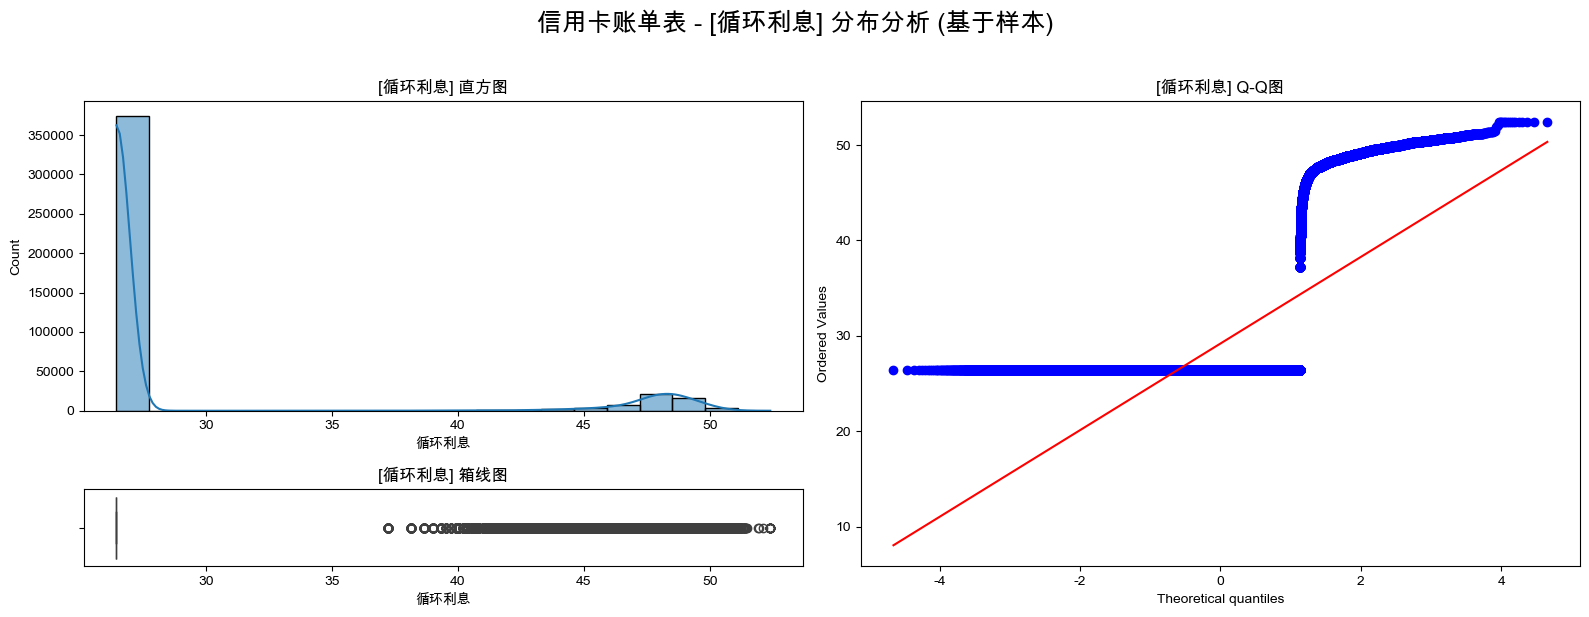


------------------------- [📊 自动解读: 循环利息] -------------------------
- **中心趋势**: 均值为 29.19，中位数为 26.46。
----------------------------------------------------------------------------


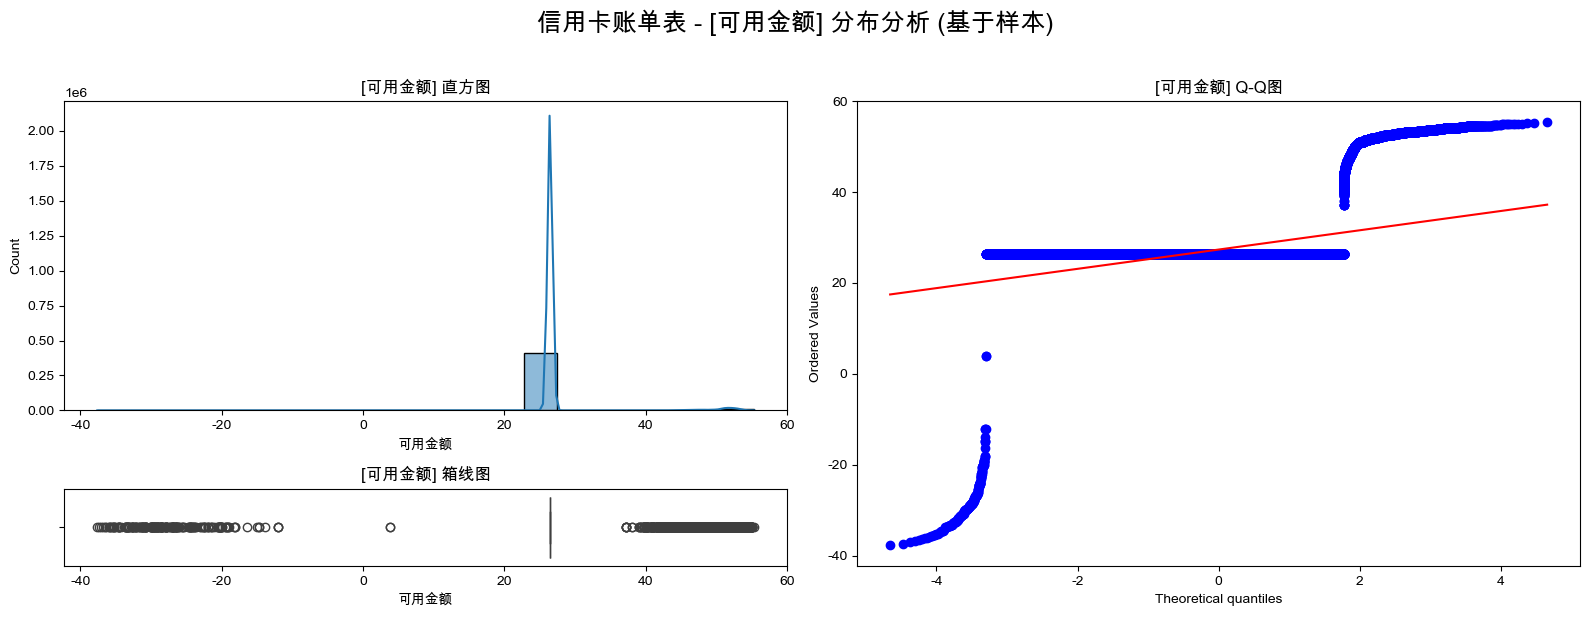


------------------------- [📊 自动解读: 可用金额] -------------------------
- **中心趋势**: 均值为 27.35，中位数为 26.46。
----------------------------------------------------------------------------


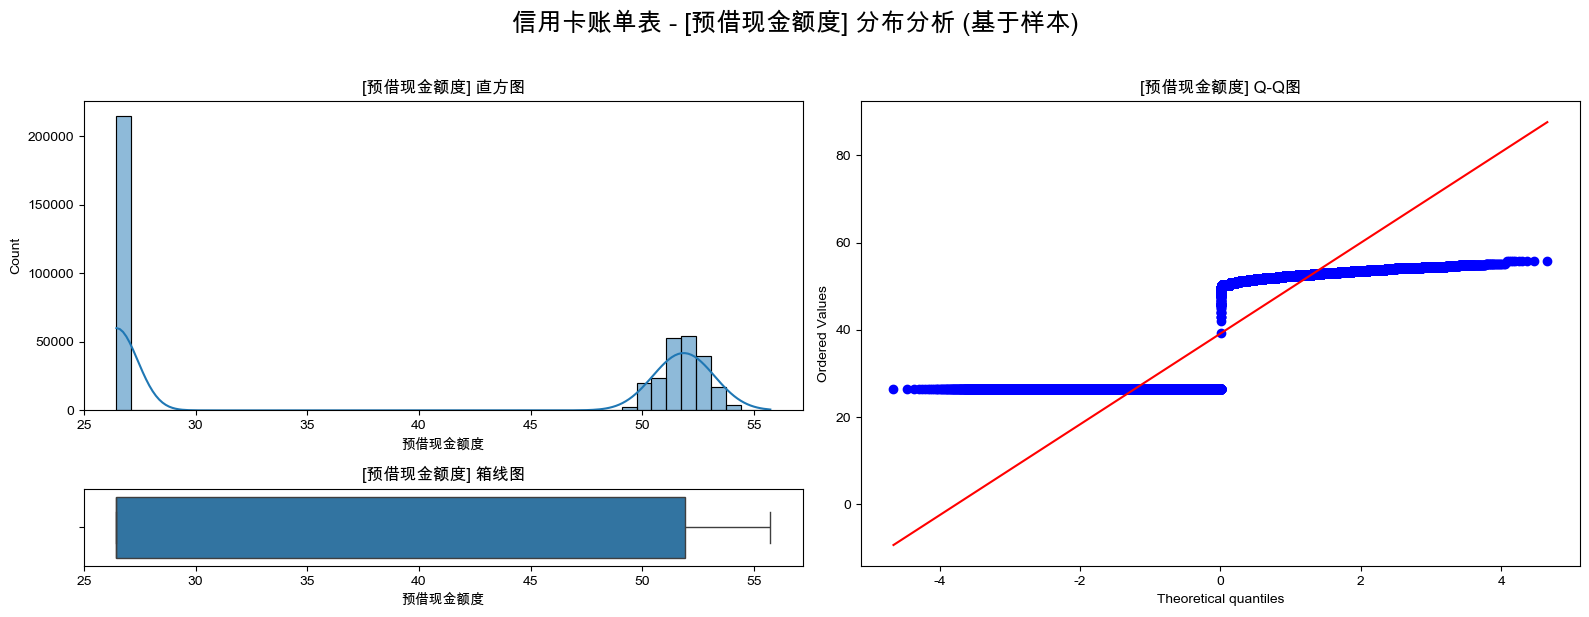


------------------------- [📊 自动解读: 预借现金额度] -------------------------
- **中心趋势**: 均值为 39.13，中位数为 26.46。
------------------------------------------------------------------------------


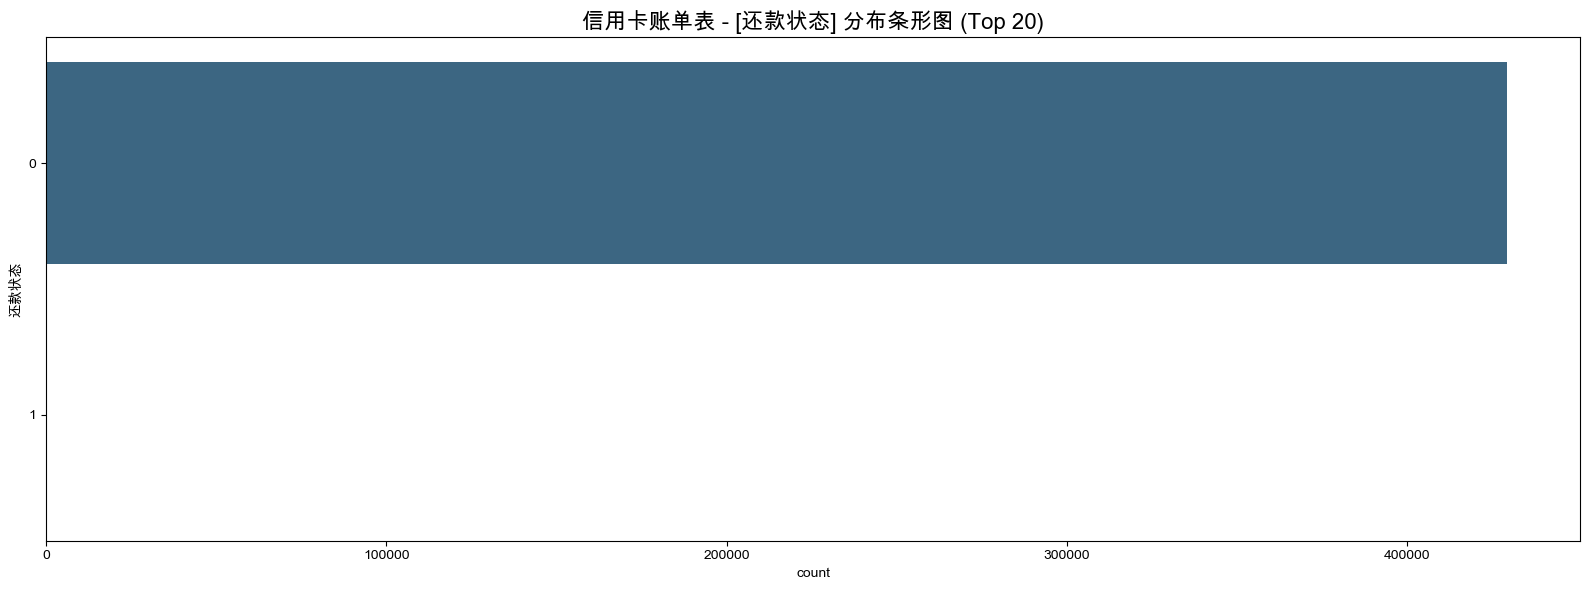


------------------------- [📊 自动解读: 还款状态] -------------------------
- **主要发现**: 该字段共有 2 个不同类别。
- **主导类别**: '0' 是最常见的类别，出现了 429365 次，占比 99.98%。
----------------------------------------------------------------------------
------------------------- 开始绘制 信用卡账单表 的关键关系图 -------------------------


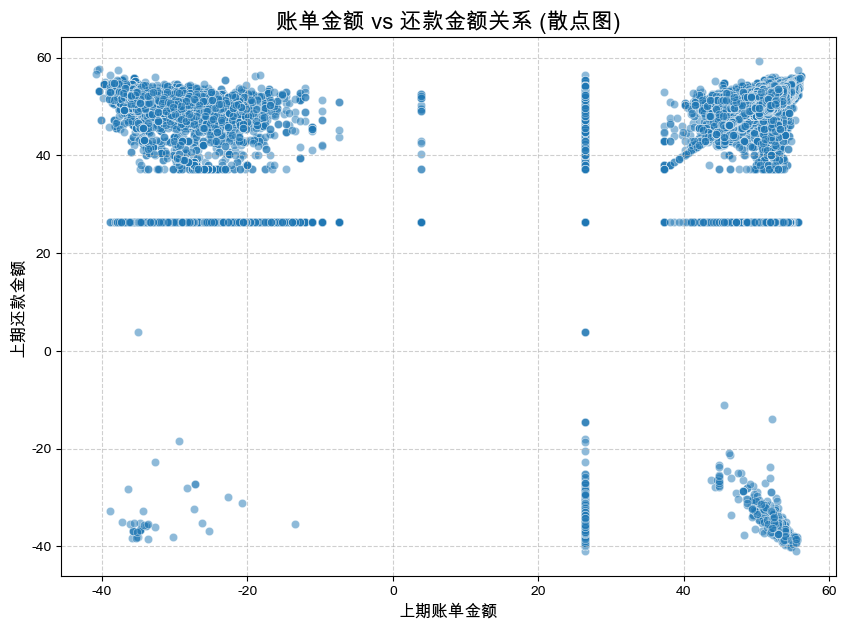

✅ 绘制 [账单金额 vs 还款金额关系 (散点图)] 完成，耗时: 0.37 秒


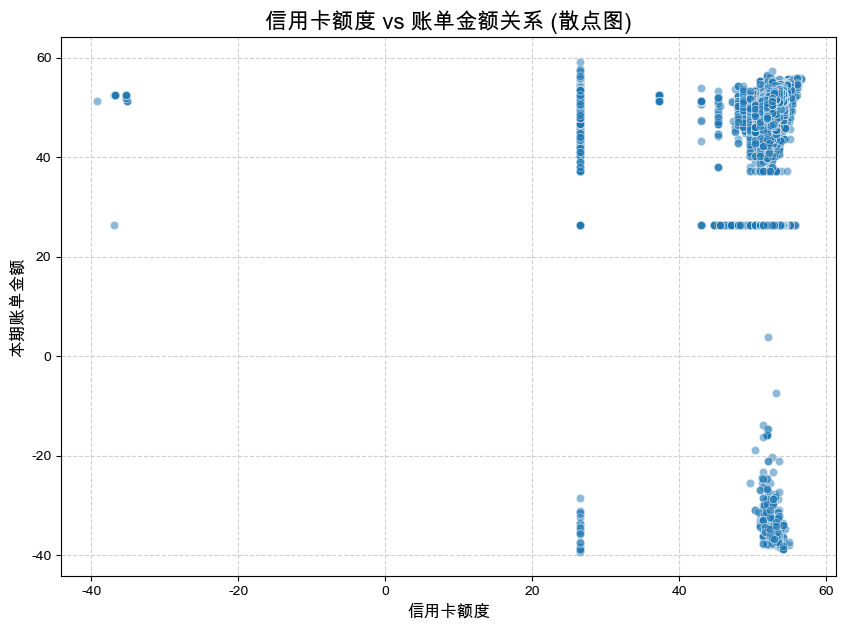

✅ 绘制 [信用卡额度 vs 账单金额关系 (散点图)] 完成，耗时: 0.38 秒


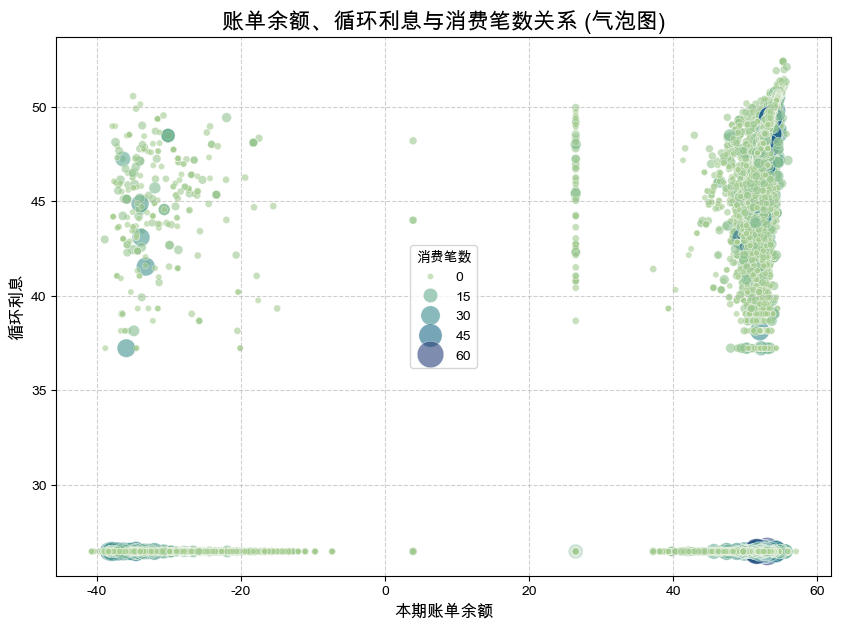

✅ 绘制 [账单余额、循环利息与消费笔数关系 (气泡图)] 完成，耗时: 9.49 秒

######################################################################
# 逾_overdue期信息表                                                      #
######################################################################
| 说明: ...
| 维度: 10000 行 x 3 列
######################################################################


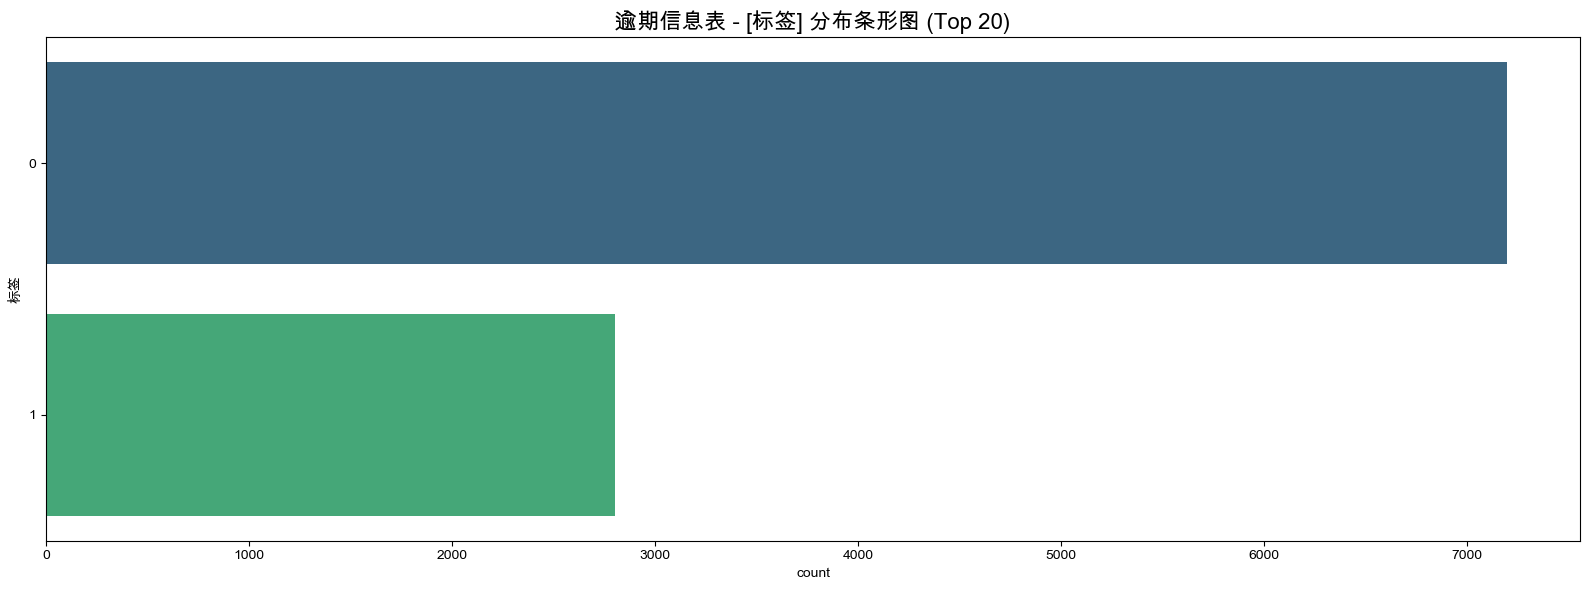


------------------------- [📊 自动解读: 标签] -------------------------
- **主要发现**: 该字段共有 2 个不同类别。
- **主导类别**: '0' 是最常见的类别，出现了 7198 次，占比 71.98%。
--------------------------------------------------------------------------


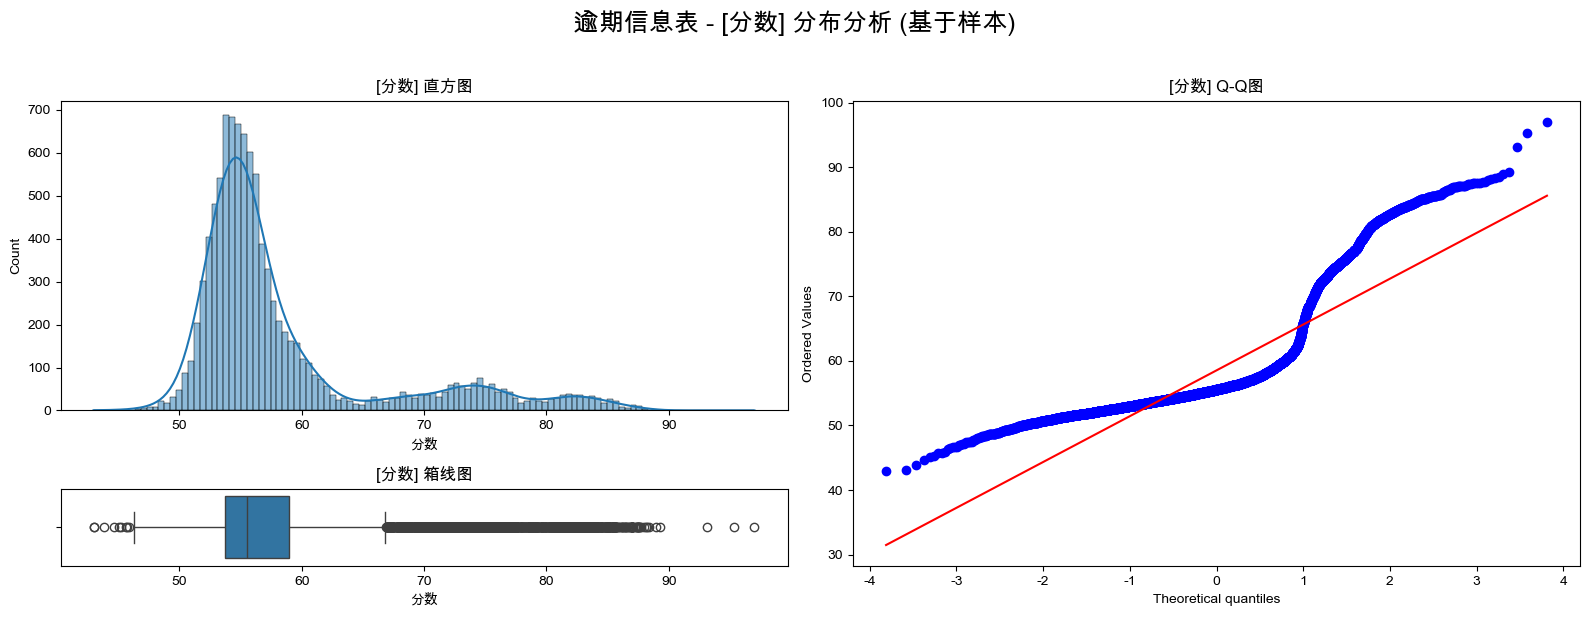


------------------------- [📊 自动解读: 分数] -------------------------
- **中心趋势**: 均值为 58.53，中位数为 55.56。
--------------------------------------------------------------------------

--- 高效可视化与解读已完成 ---


In [42]:
# 可视化数据探索
# 确保所有变量和设置都已定义 
ENABLE_PLOTTING = True
ENABLE_SAMPLING = True
SAMPLE_SIZE = 1000000
CARDINALITY_LIMIT = 40

COLUMNS_TO_EXCLUDE = [
    '交易时间戳', '账单时间戳', '账单时间', '账单年', '账单月', '账单日', 
    '账单时', '账单分', '账单秒', '交易时间', '交易年', '交易月', 
    '交易日', '交易时', '交易分', '交易秒'
]

#===========函数定义区===========

def print_table_description(df, table_name, description):
    
    print("\n" + "#"*70)
    print(f"# {table_name}".ljust(69) + "#")
    print("#"*70)
    print(f"| 说明: {description}")
    print(f"| 维度: {df.shape[0]} 行 x {df.shape[1]} 列")
    print("#"*70)

def generate_automated_interpretation(series, column_name):
    '''
    自动生成对单个字段的解读报告。
    '''
    # ... (此函数定义与之前相同)
    print("\n" + "-"*25 + f" [📊 自动解读: {column_name}] " + "-"*25)
    if series.dtype == 'object' or series.nunique() <= CARDINALITY_LIMIT:
        counts = series.value_counts()
        if not counts.empty:
            mode = counts.index[0]
            mode_freq = counts.iloc[0]
            mode_percentage = (mode_freq / len(series.dropna())) * 100
            print(f"- **主要发现**: 该字段共有 {series.nunique()} 个不同类别。")
            print(f"- **主导类别**: '{mode}' 是最常见的类别，出现了 {mode_freq} 次，占比 {mode_percentage:.2f}%。")
    else:
        desc = series.describe()
        mean, median, std = desc['mean'], desc['50%'], desc['std']
        print(f"- **中心趋势**: 均值为 {mean:.2f}，中位数为 {median:.2f}。")
    print("-" * (72 + len(column_name)))


def optimized_visualize(df, table_name):
    """
    可视化函数(优化运行速度与内存使用)。
    """
    plot_df = df
    if ENABLE_SAMPLING and len(df) > SAMPLE_SIZE:
        print(f"| 提示: 数据量较大，将使用 {SAMPLE_SIZE} 行的随机样本进行绘图...")
        plot_df = df.sample(n=SAMPLE_SIZE, random_state=42)
    for column in df.columns:
        if column == 'new_user_id' or column in COLUMNS_TO_EXCLUDE or df[column].nunique() <= 1:
            continue
        plt.figure(figsize=(16, 6))
        if df[column].dtype == 'object' or (np.issubdtype(df[column].dtype, np.integer) and df[column].nunique() <= CARDINALITY_LIMIT):
            sns.countplot(y=df[column], order=df[column].value_counts().nlargest(20).index, hue=df[column], palette='viridis', legend=False)
            plt.title(f'{table_name} - [{column}] 分布条形图 (Top 20)', fontsize=16)
        else:
            spec = plt.GridSpec(ncols=2, nrows=2, height_ratios=[4, 1])
            ax1 = plt.subplot(spec[0, 0]); sns.histplot(plot_df[column], kde=True, ax=ax1); ax1.set_title(f'[{column}] 直方图')
            ax2 = plt.subplot(spec[1, 0], sharex=ax1); sns.boxplot(x=plot_df[column], ax=ax2); ax2.set_title(f'[{column}] 箱线图')
            ax3 = plt.subplot(spec[:, 1]); stats.probplot(plot_df[column].dropna(), dist="norm", plot=ax3); ax3.set_title(f'[{column}] Q-Q图')
            plt.suptitle(f'{table_name} - [{column}] 分布分析 (基于样本)', fontsize=18, y=1.02)
        plt.tight_layout()
        plt.show()
        generate_automated_interpretation(df[column], column)


def plot_key_relationships(df, table_name):
    """
    专门用于绘制字段间关系图（散点图、气泡图）的函数。
    """
    plot_df = df
    if ENABLE_SAMPLING and len(df) > SAMPLE_SIZE:
        plot_df = df.sample(n=SAMPLE_SIZE, random_state=42)
        
    print(f" 开始绘制 {table_name} 的关键关系图 ".center(70, "-"))
    
    plots_to_create = []
    if table_name == "信用卡账单表":
        plots_to_create = [
            {'type': 'scatter', 'x': '上期账单金额', 'y': '上期还款金额', 'title': '账单金额 vs 还款金额关系 (散点图)'},
            {'type': 'scatter', 'x': '信用卡额度', 'y': '本期账单金额', 'title': '信用卡额度 vs 账单金额关系 (散点图)'},
            {'type': 'bubble', 'x': '本期账单余额', 'y': '循环利息', 'size': '消费笔数', 'title': '账单余额、循环利息与消费笔数关系 (气泡图)'}
        ]
    
    for plot_config in plots_to_create:
        start_time = time.time()
        plt.figure(figsize=(10, 7))
        
        if plot_config['type'] == 'scatter':
            sns.scatterplot(data=plot_df, x=plot_config['x'], y=plot_config['y'], alpha=0.5)
        elif plot_config['type'] == 'bubble':
            sns.scatterplot(data=plot_df, x=plot_config['x'], y=plot_config['y'], size=plot_config['size'], 
                            sizes=(20, 400), alpha=0.6, hue=plot_config['size'], palette='crest')
        
        plt.title(plot_config['title'], fontsize=16)
        plt.xlabel(plot_config['x'], fontsize=12)
        plt.ylabel(plot_config['y'], fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
        end_time = time.time()
        print(f"✅ 绘制 [{plot_config['title']}] 完成，耗时: {end_time - start_time:.2f} 秒")



if ENABLE_PLOTTING:
    # 1. 用户基本信息表
    print_table_description(df_user_info_cleaned, "用户基本信息表", "...")
    optimized_visualize(df_user_info_cleaned, "用户基本信息表 (清洗后, 编码前)") 
    
    # 2. 银行流水表
    print_table_description(df_bank, "银行流水表", "...")
    optimized_visualize(df_bank, "银行流水表")
    
    # 3. 信用卡账单表
    print_table_description(df_bill, "信用卡账单表", "...")
    optimized_visualize(df_bill, "信用卡账单表")
    # 现在调用不会再报错
    plot_key_relationships(df_bill, "信用卡账单表") 
    
    # 4. 逾期信息表
    print_table_description(df_overdue, "逾_overdue期信息表", "...")
    optimized_visualize(df_overdue, "逾期信息表")
    
    print("\n--- 高效可视化与解读已完成 ---")
else:
    print("--- 可视化分析已禁用 ---")

## 3. 数据预处理（特征指标构建）
通过对数据进行清洗和可视化分析之后，构建相应的一些信用风险评估特征指标来进行进一步分析，为模型预测做准备。

### 3.1 合并数据
由于四张表的`new_user_id`数量并不一致。所以先对各个表的特征指标进行构建，再合并为可用数据。

#### 3.1.1 银行流水表（bank）

In [43]:

print(" 开始执行: 银行流水表特征工程 ".center(70, "="))


# --- 为了计算收入/支出，我们先定义交易类型 ---
# 假设 交易类型 0=支出, 1=收入 (如果实际情况相反，请调整)
df_bank['收入金额'] = df_bank.apply(lambda row: row['交易金额'] if row['交易类型'] == 1 else 0, axis=1)
df_bank['支出金额'] = df_bank.apply(lambda row: row['交易金额'] if row['交易类型'] == 0 else 0, axis=1)

# 按用户ID进行分组聚合
bank_features = df_bank.groupby('new_user_id').agg(
    # 交易频率
    bank_交易总笔数=('new_user_id', 'size'),
    
    # 收入相关
    bank_总收入=('收入金额', 'sum'),
    bank_平均单笔收入=('收入金额', lambda x: x[x > 0].mean()), # 只计算有收入的平均值
    bank_最大单笔收入=('收入金额', 'max'),
    bank_工资收入笔数=('工资收入标记', 'sum'),
    
    # 支出相关
    bank_总支出=('支出金额', 'sum'),
    bank_平均单笔支出=('支出金额', lambda x: x[x > 0].mean()), # 只计算有支出的平均值
    bank_最大单笔支出=('支出金额', 'max'),
    
    # 交易金额总体特征
    bank_交易金额均值=('交易金额', 'mean'),
    bank_交易金额标准差=('交易金额', 'std'),
).reset_index()

# 构造一个净收入特征
bank_features['bank_净收入'] = bank_features['bank_总收入'] - bank_features['bank_总支出']

# 填充聚合后可能产生的NaN值 (例如，某个用户可能只有支出没有收入)
bank_features.fillna(0, inplace=True)

print("银行流水特征工程完成。")
print("生成的特征表示例 (前5行):")
print(bank_features.head())

========================== 开始执行: 银行流水表特征工程 ===========================
银行流水特征工程完成。
生成的特征表示例 (前5行):
                        new_user_id  bank_交易总笔数      bank_总收入  bank_平均单笔收入  \
0  0003f283dfacd7100bba76d876cf94da         154   4570.785390    41.178247   
1  00284cf15ae27d1ddf4f93922cd7bcb5        2000  60546.818365    45.626841   
2  00375b8a7a62da4f578f4f4464fc4228         465  12153.317912    44.355175   
3  0057bbe021e9c3fc79834e3ff126bb98         367  11545.769269    43.405148   
4  00872649357929f1f3d7fafbe484810b          65   2042.297701    43.453143   

   bank_最大单笔收入  bank_工资收入笔数      bank_总支出  bank_平均单笔支出  bank_最大单笔支出  \
0    47.108117            0   1881.321862    43.751671    48.266228   
1    50.408951            0  31406.338786    46.666179    49.442433   
2    49.442433            4   8553.577580    44.783129    50.060691   
3    48.209510            0   4561.888566    45.167214    48.020046   
4    46.749626            5    785.199403    43.622189    47.502580   

   ba

#### 3.1.2 信用卡账单表（bill）

In [44]:
print(" 开始执行: 信用卡账单表特征工程 ".center(70, "="))

df_bill['上期账单金额_safe'] = df_bill['上期账单金额'].replace(0, np.nan)
df_bill['信用卡额度_safe'] = df_bill['信用卡额度'].replace(0, np.nan)

bill_features = df_bill.groupby('new_user_id').agg(
    bill_账单总数=('new_user_id', 'size'),
    bill_涉及银行数=('银行id', 'nunique'),
    bill_总消费金额=('本期账单金额', 'sum'),
    bill_平均月消费金额=('本期账单金额', 'mean'),
    bill_总消费笔数=('消费笔数', 'sum'),
    bill_平均信用卡额度=('信用卡额度', 'mean'),
    bill_最大信用卡额度=('信用卡额度', 'max'),
    bill_总还款金额=('上期还款金额', 'sum'),
    bill_循环利息总额=('循环利息', 'sum'),
    bill_循环利息次数=('循环利息', lambda x: (x > 0).sum()),
).reset_index()

# --- 构造关键的比率特征 ---
bill_features['bill_还款率'] = bill_features['bill_总还款金额'] / (bill_features['bill_总消费金额'] + 1e-6)

# --- !! 此处为修改点 !! ---
# 信用额度使用率 (修复警告)
# 先选择需要的列，再应用函数，更高效且无警告
avg_utilization = df_bill.groupby('new_user_id')[['本期账单余额', '信用卡额度_safe']].apply(
    lambda x: (x['本期账单余额'] / x['信用卡额度_safe']).mean()
).reset_index(name='bill_平均信用使用率')

# 合并使用率特征
bill_features = pd.merge(bill_features, avg_utilization, on='new_user_id', how='left')
bill_features.fillna(0, inplace=True)

print("信用卡账单特征工程完成。")
print("生成的特征表示例 (前5行):")
print(bill_features.head().to_string())


========================== 开始执行: 信用卡账单表特征工程 ==========================
信用卡账单特征工程完成。
生成的特征表示例 (前5行):
                        new_user_id  bill_账单总数  bill_涉及银行数   bill_总消费金额  bill_平均月消费金额  bill_总消费笔数  bill_平均信用卡额度  bill_最大信用卡额度   bill_总还款金额  bill_循环利息总额  bill_循环利息次数  bill_还款率  bill_平均信用使用率
0  0000a11bede26d01990cd7bf86a4ffed         24           3  1149.975912     47.915663           1     51.686795     51.933872  1126.748311   862.534041           24  0.979802      0.999978
1  0001102f53f24a8952ed5b47f9564354         15           2   422.949602     28.196640           6     51.857833     52.496721   625.086650   396.862697           15  1.477922      0.833627
2  000228d848615f1320914e0cf6064d12          1           1    51.750090     51.750090           0     51.439717     51.439717    50.809535    45.959432            1  0.981825      0.997087
3  0003f283dfacd7100bba76d876cf94da         11           1   501.886409     45.626037           4     46.014530     50.360533   492.807745   291

#### 最终合并

In [45]:
print("\n" + "="*70)
print(" 开始执行: 最终数据合并 (严格筛选策略) ".center(70, "="))
print("="*70)

# --- 1. 从编码后的用户信息表开始 ---
df_final_model = df_user_info_encoded.copy()
print(f"起始表 (用户信息): {df_final_model.shape}")

# --- 2. 合并 逾期信息表 (目标标签) ---
df_target = df_overdue[['new_user_id', '标签','分数']].copy()
# --- 关键变更: 使用 'inner' join，确保每个用户都有标签 ---
df_final_model = pd.merge(df_final_model, df_target, on='new_user_id', how='inner')
print(f"合并标签后 (inner join): {df_final_model.shape}")

# --- 3. 合并 银行流水特征 ---
# --- 关键变更: 使用 'inner' join，只保留有银行流水的用户 ---
df_final_model = pd.merge(df_final_model, bank_features, on='new_user_id', how='inner')
print(f"合并银行特征后 (inner join): {df_final_model.shape}")

# --- 4. 合并 信用卡账单特征 ---
# --- 关键变更: 使用 'inner' join，只保留同时也有信用卡账单的用户 ---
df_final_model = pd.merge(df_final_model, bill_features, on='new_user_id', how='inner')
print(f"合并账单特征后 (inner join): {df_final_model.shape}")

# --- 5. 最后的检查与清理 ---
#    虽然 inner join 避免了因合并产生的NaN，但特征工程本身可能产生NaN，
#    所以 .fillna(0) 仍然是一个好习惯，作为最后的保险。
final_nan_check_before = df_final_model.isnull().sum().sum()
if final_nan_check_before > 0:
    print(f"[!] 在合并后、填充前，发现 {final_nan_check_before} 个缺失值，将用0填充。")
    df_final_model.fillna(0, inplace=True)


print("\n" + "-"*70)
print("✅ [任务完成] 严格筛选后的最终建模数据已生成！")
print(f"最终维度: {df_final_model.shape[0]} 用户, {df_final_model.shape[1]} 列")
print("说明: 这里的每一个用户都保证拥有完整的用户、银行和账单信息。")
print("-" * 70)
print("\n最终建模数据表示例 (前5行):")
df_final_model.head(5)


======================= 开始执行: 最终数据合并 (严格筛选策略) ========================
起始表 (用户信息): (9715, 20)
合并标签后 (inner join): (9715, 22)
合并银行特征后 (inner join): (1653, 33)
合并账单特征后 (inner join): (1305, 45)

----------------------------------------------------------------------
✅ [任务完成] 严格筛选后的最终建模数据已生成！
最终维度: 1305 用户, 45 列
说明: 这里的每一个用户都保证拥有完整的用户、银行和账单信息。
----------------------------------------------------------------------

最终建模数据表示例 (前5行):


,new_user_id,性别_女,性别_男,职业_事业单位,职业_企业,职业_公职,职业_无业,教育程度_初中及以下,教育程度_大专,教育程度_本科及以上,...,bill_总消费金额,bill_平均月消费金额,bill_总消费笔数,bill_平均信用卡额度,bill_最大信用卡额度,bill_总还款金额,bill_循环利息总额,bill_循环利息次数,bill_还款率,bill_平均信用使用率
0,0c87f6b1f7e0350a35841ba34df9d26a,False,True,False,False,True,False,False,False,True,...,698.817709,41.106924,1,41.152927,51.439717,696.797968,449.777723,17,0.997110,1.382751
1,74c53a62f15cc039864aefc41170f81b,False,True,False,False,True,False,False,True,False,...,1241.766880,35.479054,0,36.348366,53.152802,1211.846993,926.012959,35,0.975905,1.190742
2,f252acaac66355ee480542cb658036f9,False,True,False,False,True,False,False,False,True,...,1247.336468,47.974480,28,50.098373,52.687501,1294.839633,687.895341,26,1.038084,0.787943
3,7a14edc976b9013cce0af0b505e684f1,True,False,False,False,True,False,False,False,True,...,5049.738313,41.054783,59,47.445238,52.596975,5000.478508,3254.274113,123,0.990245,1.157981
4,a7edf3699fe73361416d06d2269cab41,False,True,False,True,False,False,False,False,True,...,3368.643680,48.820923,0,51.426657,52.109109,3358.812419,2243.236209,69,0.997082,0.994227


### 3.2 新表预处理

#### 3.2.1 检查缺失值

In [46]:
# 检查缺失值
print("\n" + "="*70)
print(" 开始执行: 最终建模数据缺失值统计 ".center(70, "="))
print("="*70)

# --- 计算每列的缺失值数量 ---
missing_values = df_final_model.isnull().sum()

# --- 筛选出真正存在缺失值的列 ---
missing_values_report = missing_values[missing_values > 0]

# --- 打印报告 ---
if missing_values_report.empty:
    print("✅ [检查通过] 最终建模数据集 (df_final_model) 中已无任何缺失值。")
else:
    print("⚠️ [发现问题] 最终建模数据集 (df_final_model) 中仍存在以下缺失值：\n")
    
    # 创建一个美化的统计DataFrame
    missing_df = pd.DataFrame({
        '字段名': missing_values_report.index,
        '缺失数量': missing_values_report.values,
        '缺失比例 (%)': (missing_values_report / len(df_final_model) * 100).round(2)
    })
    
    # 打印美化后的表格
    print(missing_df.to_string(index=False))
    
    print("\n[建议]: 请检查数据合并流程中的 merge 方式或最后的 .fillna() 操作。")

print("="*70)


========================= 开始执行: 最终建模数据缺失值统计 ==========================
✅ [检查通过] 最终建模数据集 (df_final_model) 中已无任何缺失值。


In [47]:
# 显示最终数据集的前100行
df_final_model.head(100)

,new_user_id,性别_女,性别_男,职业_事业单位,职业_企业,职业_公职,职业_无业,教育程度_初中及以下,教育程度_大专,教育程度_本科及以上,...,bill_总消费金额,bill_平均月消费金额,bill_总消费笔数,bill_平均信用卡额度,bill_最大信用卡额度,bill_总还款金额,bill_循环利息总额,bill_循环利息次数,bill_还款率,bill_平均信用使用率
0,0c87f6b1f7e0350a35841ba34df9d26a,False,True,False,False,True,False,False,False,True,...,698.817709,41.106924,1,41.152927,51.439717,696.797968,449.777723,17,0.997110,1.382751
1,74c53a62f15cc039864aefc41170f81b,False,True,False,False,True,False,False,True,False,...,1241.766880,35.479054,0,36.348366,53.152802,1211.846993,926.012959,35,0.975905,1.190742
2,f252acaac66355ee480542cb658036f9,False,True,False,False,True,False,False,False,True,...,1247.336468,47.974480,28,50.098373,52.687501,1294.839633,687.895341,26,1.038084,0.787943
3,7a14edc976b9013cce0af0b505e684f1,True,False,False,False,True,False,False,False,True,...,5049.738313,41.054783,59,47.445238,52.596975,5000.478508,3254.274113,123,0.990245,1.157981
4,a7edf3699fe73361416d06d2269cab41,False,True,False,True,False,False,False,False,True,...,3368.643680,48.820923,0,51.426657,52.109109,3358.812419,2243.236209,69,0.997082,0.994227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4fb7354dabbefcd8899cd69794a2d2aa,False,True,False,False,True,False,False,True,False,...,538.583543,48.962140,17,51.860538,52.596975,510.048375,389.949902,11,0.947018,0.998780
96,88651292354fbeea181941283411093b,False,True,False,False,True,False,False,True,False,...,3225.619590,43.589454,129,49.077716,54.523491,3326.400131,1957.855970,74,1.031244,1.070819
97,3e3cf6190aba86c72cbe81083892c8d8,False,True,False,False,True,False,False,True,False,...,2142.720720,26.784009,12,48.774941,52.596975,2116.601049,2116.601049,80,0.987810,1.116395
98,05f3326956d16f1c62fa89e605ec423f,False,True,True,False,False,False,False,False,True,...,1197.605604,49.900234,0,51.537872,51.832335,1105.962977,634.980315,24,0.923478,0.919611


In [48]:
df_final_model.describe()

,标签,分数,bank_交易总笔数,bank_总收入,bank_平均单笔收入,bank_最大单笔收入,bank_工资收入笔数,bank_总支出,bank_平均单笔支出,bank_最大单笔支出,...,bill_总消费金额,bill_平均月消费金额,bill_总消费笔数,bill_平均信用卡额度,bill_最大信用卡额度,bill_总还款金额,bill_循环利息总额,bill_循环利息次数,bill_还款率,bill_平均信用使用率
count,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,...,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000
mean,0.802299,76.098168,658.662835,20278.378159,43.005187,48.110231,4.236782,8398.997026,44.366369,48.797739,...,2456.574947,41.931174,66.409195,47.104347,51.475780,2519.342058,1683.411278,57.121073,1.047926,1.097385
std,0.398418,5.762475,558.391446,17741.859827,1.236953,1.199410,19.061288,7644.450833,1.709505,1.947483,...,4891.252731,8.447547,205.794740,7.199907,5.803261,4931.451918,3345.770196,109.599105,0.210350,0.291416
min,0.000000,59.310867,4.000000,83.074862,36.006985,39.317371,0.000000,0.000000,0.000000,0.000000,...,26.457513,20.235346,0.000000,26.457513,26.457513,8.587547,26.457513,1.000000,0.041173,-0.756992
25%,1.000000,72.329521,270.000000,7929.032906,42.238770,47.292812,0.000000,3293.609949,43.642480,47.910215,...,414.316811,36.337864,1.000000,44.168673,52.025552,420.542391,282.987624,10.000000,0.968495,0.982314
50%,1.000000,75.323886,495.000000,15266.329471,42.963073,48.020046,0.000000,6280.565143,44.404714,48.736429,...,1104.630630,43.794914,14.000000,50.490270,52.687501,1126.756716,740.810367,26.000000,0.998828,0.999359
75%,1.000000,81.151434,898.000000,27276.625316,43.758091,48.923119,3.000000,11152.603427,45.156183,49.667581,...,2604.130145,49.313875,58.000000,52.078332,53.422735,2601.442664,1719.738352,61.000000,1.034540,1.202412
max,1.000000,97.000000,5357.000000,176168.483246,47.863440,52.384419,491.000000,97880.514061,48.821782,54.658062,...,67538.418169,54.446192,4777.000000,54.207460,55.371608,64257.342811,47332.797789,1429.000000,2.012671,2.024227


#### 3.2.2 保存新表
将合并清洗完成之后的新表保存为`.csv`文件，为后续模型预测做准备

In [49]:
import pandas as pd
import numpy as np
import os 


# ==============================================================================
# --- 最終階段：將最終建模資料匯出到指定文件夾 ---
# ==============================================================================
print("\n" + "="*70)
print(" 保存清洗过的数据到新的csv文件 ".center(70, "="))
print("="*70)

# --- 1. 定義輸出文件夾和檔名 ---
output_directory = "OutputData_COB"  # 指定輸出資料夾名稱
output_filename = "final_modeling_dataset.csv"

# --- 2. 建立完整的檔案路徑 ---
# os.path.join 會根據您的作業系統（Mac, Windows）自動使用正確的路徑分隔符（/ 或 \）
output_path = os.path.join(output_directory, output_filename)

try:
    # --- 3. 新增：檢查並建立輸出資料夾 ---
    # 檢查名為 'outputfile' 的資料夾是否存在
    if not os.path.exists(output_directory):
        # 如果不存在，則建立它
        os.makedirs(output_directory)
        print(f"📁 資料夾 '{output_directory}' 不存在，已自動建立。")

    # --- 4. 核心匯出步驟 (使用新的 output_path) ---
    # index=False: 不將DataFrame的索引寫入檔案
    # encoding='utf-8-sig': 確保跨平台相容性，特別是用Excel開啟時中文不會亂碼
    df_final_model.to_csv(output_path, index=False, encoding='utf-8-sig')
    
    # --- 5. 更新成功訊息 ---
    print(f"✅ 資料匯出成功！")
    print(f"   最終的建模資料已儲存至: {output_path}")
    print(f"   檔案包含 {df_final_model.shape[0]} 筆資料 (用戶) 和 {df_final_model.shape[1]} 個欄位 (特徵)。")

except Exception as e:
    # --- 打印錯誤訊息 ---
    print(f"❌ 資料匯出失敗。錯誤訊息: {e}")

print("\n--- 所有流程已完成 ---")


========================== 保存清洗过的数据到新的csv文件 ==========================
✅ 資料匯出成功！
   最終的建模資料已儲存至: OutputData_COB/final_modeling_dataset.csv
   檔案包含 1305 筆資料 (用戶) 和 45 個欄位 (特徵)。

--- 所有流程已完成 ---


## 4. 模型预测
模型预测包括单变量和多变量线性回归模型预测、逻辑回归模型预测

### 4.1 线性模型 

In [50]:
import pandas as pd
import os
# 解决中文显示问题
# 设置全局字体
plt.rcParams["font.family"] = ["Arial Unicode MS"] # Mac系统
plt.rcParams['axes.unicode_minus']=False # 解决负号'-'显示为
# 查看要使用的数据集合
data = pd.read_csv(os.path.join('OutputData_COB', 'final_modeling_dataset.csv'))
# 将标签列重命名为is_overdue
data = data.rename(columns={"标签": "is_overdue"})


* 对综合信用得分进行训练预测（`y=分数`）

--- 1. 准备数据 ---
目标变量 y 的维度: (1305,)
特征 X 的维度: (1305, 42)

--- 划分数据集 (80% 训练集, 20% 测试集) ---
训练集样本量: 1044 个用户
测试集样本量: 261 个用户

--- 3. 使用 StandardScaler 标准化特征 ---
特征已成功标准化。

--- 4. 训练线性回归模型 ---
模型训练完成。

--- 5. 评估模型性能 ---

[核心评估指标]
均方误差 (MSE): 49.28
均方根误差 (RMSE): 7.02
R² (决定系数): -0.48  (这意味着我们的模型可以解释信用分数中 -47.5% 的变异)

[业务一致性检验]
未逾期用户(0)的平均预测分: 76.86
已逾期用户(1)的平均预测分:    76.18
✅ [检验通过]: 模型表现符合业务预期，成功给未逾期用户打出了更高的分数。

--- 6. 结果可视化与特征重要性分析 ---


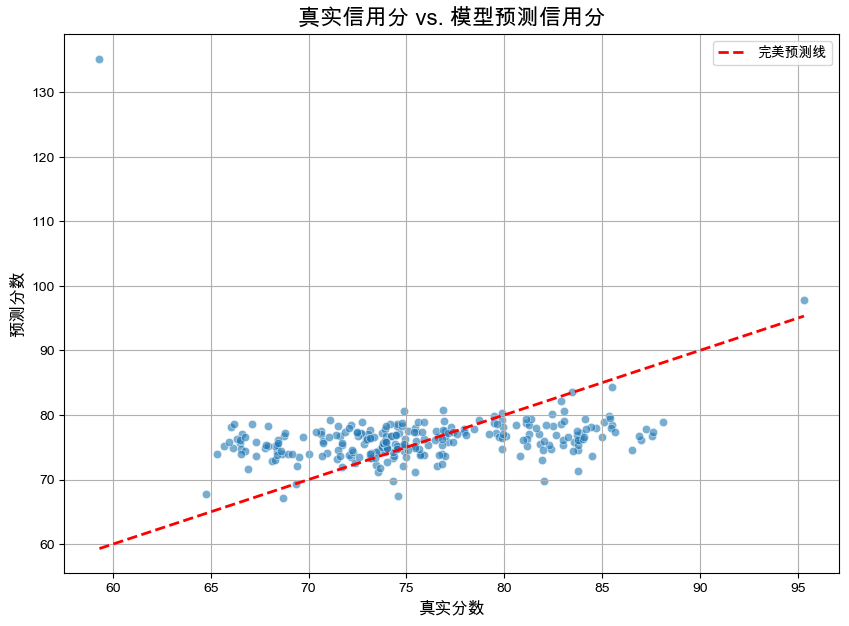


[特征重要性分析 (模型系数)]
对信用分有最大正向影响的特征 (使分数升高):
bank_交易总笔数      7.291625
bill_总还款金额      2.362743
bank_交易金额均值     2.277345
bank_工资收入笔数     1.570912
bill_平均信用使用率    1.079195
职业_公职           0.683068
bank_最大单笔收入     0.608013
bill_平均信用卡额度    0.469851
bill_平均月消费金额    0.331533
户口类型_其他户口       0.234465
dtype: float64

对信用分有最大负向影响的特征 (使分数降低):
户口类型_集体户口     -0.286149
bill_循环利息总额   -0.441014
bank_平均单笔收入   -0.552143
职业_事业单位       -0.623051
bank_平均单笔支出   -0.793508
bank_最大单笔支出   -0.924866
bank_净收入      -1.184815
bill_总消费金额    -2.081536
bank_总收入      -2.429312
bank_总支出      -3.713121
dtype: float64


In [52]:
# 线性模型预测
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
# 数据准备
print("--- 1. 准备数据 ---")
# 目标变量 'y' 是信用分数
y = data['分数']
# 特征变量 'X' 是除 '分数' 和 'is_overdue' 之外的所有列
X = data.drop(columns=['分数', 'is_overdue', 'new_user_id'])

print(f"目标变量 y 的维度: {y.shape}")
print(f"特征 X 的维度: {X.shape}")

# ==============================================================================
# --- 步骤 2: 划分训练集和测试集 ---
# ==============================================================================
print("\n--- 划分数据集 (80% 训练集, 20% 测试集) ---")

# 我们基于 'is_overdue' 列进行分层抽样，
# 这能确保训练集和测试集拥有相同比例的好、坏客户，使模型评估更可靠。
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,  # 设置随机种子以保证结果可复现
    stratify=data['is_overdue'] 
)

print(f"训练集样本量: {X_train.shape[0]} 个用户")
print(f"测试集样本量: {X_test.shape[0]} 个用户")

# ==============================================================================
# --- 步骤 3: 特征标准化 ---
# ==============================================================================
print("\n--- 3. 使用 StandardScaler 标准化特征 ---")

scaler = StandardScaler()

# 核心步骤：只在训练集上进行 fit_transform
X_train_scaled = scaler.fit_transform(X_train)

# 使用同一个 scaler（即用训练集的均值和标准差）来转换测试集
X_test_scaled = scaler.transform(X_test)

print("特征已成功标准化。")


# ==============================================================================
# --- 步骤 4: 模型训练 ---
# ==============================================================================
print("\n--- 4. 训练线性回归模型 ---")

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("模型训练完成。")


# ==============================================================================
# --- 步骤 5: 预测与评估 ---
# ==============================================================================
print("\n--- 5. 评估模型性能 ---")

# 在标准化后的测试集上进行预测
y_pred = model.predict(X_test_scaled)

# 计算标准的回归模型评估指标
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n[核心评估指标]")
print(f"均方误差 (MSE): {mse:.2f}")
print(f"均方根误差 (RMSE): {rmse:.2f}")
print(f"R² (决定系数): {r2:.2f}  (这意味着我们的模型可以解释信用分数中 {r2*100:.1f}% 的变异)")

# --- 业务一致性检验 ---
# 模型是否能给未逾期(is_overdue=0)的用户打出比逾期(is_overdue=1)用户更高的分数？
results_df = pd.DataFrame({
    '真实分数': y_test,
    '预测分数': y_pred,
    '是否逾期': data.loc[y_test.index, 'is_overdue']
})

consistency_check = results_df.groupby('是否逾期')['预测分数'].mean()

print(f"\n[业务一致性检验]")
print(f"未逾期用户(0)的平均预测分: {consistency_check.get(0, 0):.2f}")
print(f"已逾期用户(1)的平均预测分:    {consistency_check.get(1, 0):.2f}")

if consistency_check.get(0, 0) > consistency_check.get(1, 0):
    print("✅ [检验通过]: 模型表现符合业务预期，成功给未逾期用户打出了更高的分数。")
else:
    print("❌ [检验失败]: 模型未能给未逾期用户打出更高的分数，其内在逻辑可能存在问题。")


# ==============================================================================
# --- 步骤 6: 结果可视化与特征重要性分析 ---
# ==============================================================================
print("\n--- 6. 结果可视化与特征重要性分析 ---")

# 配置绘图环境 (macOS)
plt.rcParams['font.sans-serif'] = ['PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# --- 真实值 vs. 预测值散点图 ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='完美预测线')
plt.title('真实信用分 vs. 模型预测信用分', fontsize=16)
plt.xlabel('真实分数', fontsize=12)
plt.ylabel('预测分数', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# --- 特征重要性分析 (模型系数) ---
# 系数绝对值越大，代表该特征对分数的影响越大
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

print("\n[特征重要性分析 (模型系数)]")
print("对信用分有最大正向影响的特征 (使分数升高):")
print(coefficients.head(10))
print("\n对信用分有最大负向影响的特征 (使分数降低):")
print(coefficients.tail(10))

### 4.2 逻辑回归模型

--- 1. 准备数据 ---
目标变量 y 的维度: (1305,)
特征 X 的维度: (1305, 42)

--- 2. 划分数据集 (80% 训练集, 20% 测试集) ---
训练集样本量: 1044 个用户
测试集样本量: 261 个用户

--- 3. 使用 StandardScaler 标准化特征 ---
特征已成功标准化。

--- 4. 训练逻辑回归模型 ---
模型训练完成。

--- 5. 评估模型性能 ---


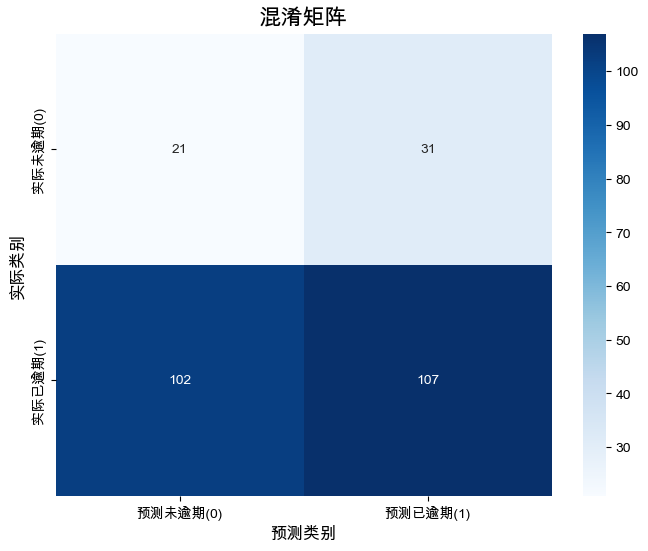


[分类报告]
              precision    recall  f1-score   support

     未逾期 (0)       0.17      0.40      0.24        52
     已逾期 (1)       0.78      0.51      0.62       209

    accuracy                           0.49       261
   macro avg       0.47      0.46      0.43       261
weighted avg       0.65      0.49      0.54       261


[AUC 值]
AUC (Area Under Curve): 0.4432


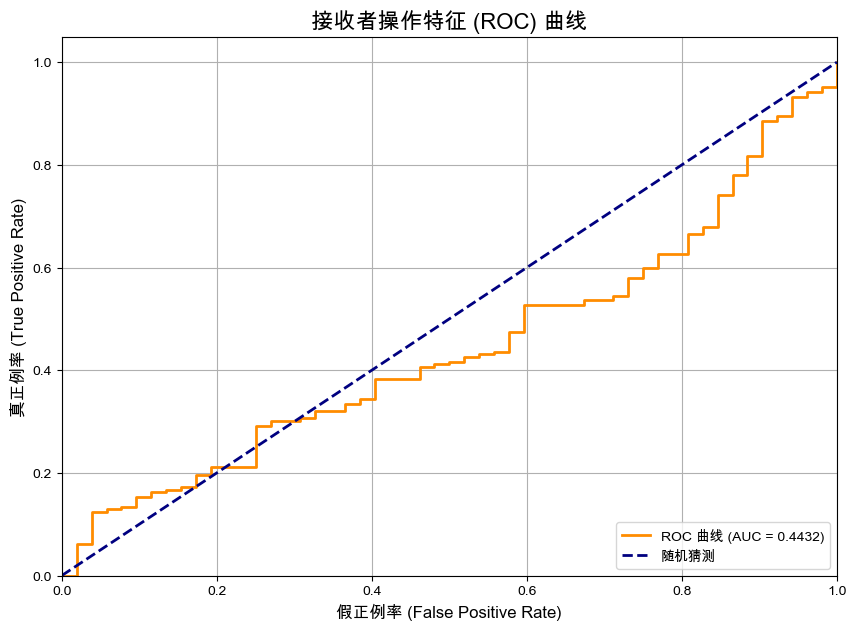


--- 6. 特征重要性分析 ---

[特征重要性分析 (模型系数)]
最能增加'逾期'概率的特征 (正系数):
bill_总还款金额      1.147072
bank_交易金额均值     0.612101
bank_工资收入笔数     0.463304
bank_交易总笔数      0.456958
bank_净收入        0.223864
职业_无业           0.173079
bank_最大单笔收入     0.149737
bill_最大信用卡额度    0.090028
职业_公职           0.086137
bill_平均月消费金额    0.081772
dtype: float64

最能降低'逾期'概率的特征 (负系数, 即增加'未逾期'概率):
教育程度_初中及以下     -0.064848
bill_总消费笔数     -0.079202
职业_企业          -0.091318
户口类型_农业户口      -0.099210
bill_平均信用卡额度   -0.105700
bank_平均单笔支出    -0.152009
bank_最大单笔支出    -0.188489
bank_总支出       -0.274315
bank_平均单笔收入    -0.424900
bill_循环利息总额    -1.144545
dtype: float64


In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


# ==============================================================================
# --- 步骤 1: 数据准备 -> 定义特征 (X) 和目标 (y) ---
# ==============================================================================
print("--- 1. 准备数据 ---")

# 目标变量 'y' 现在是 'is_overdue' (0: 未逾期, 1: 已逾期)
y = data['is_overdue']

# 特征 'X' 包含了除目标和相关标签之外的所有列
# !!关键!!: 必须同时剔除 'is_overdue'(目标) 和 '分数'(目标的强代理)，否则会造成数据泄露
X = data.drop(columns=['is_overdue', '分数', 'new_user_id'])

# 确保 ID 列也被移除
if 'new_user_id' in X.columns:
    X = X.drop(columns=['new_user_id'])

print(f"目标变量 y 的维度: {y.shape}")
print(f"特征 X 的维度: {X.shape}")


# ==============================================================================
# --- 步骤 2: 分层抽样划分数据集 (与之前相同) ---
# ==============================================================================
print("\n--- 2. 划分数据集 (80% 训练集, 20% 测试集) ---")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # 直接在目标变量y上进行分层
)

print(f"训练集样本量: {X_train.shape[0]} 个用户")
print(f"测试集样本量: {X_test.shape[0]} 个用户")


# ==============================================================================
# --- 步骤 3: 特征缩放 (标准化) (与之前相同) ---
# ==============================================================================
print("\n--- 3. 使用 StandardScaler 标准化特征 ---")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("特征已成功标准化。")


# ==============================================================================
# --- 步骤 4: 模型训练 (核心变更) ---
# ==============================================================================
print("\n--- 4. 训练逻辑回归模型 ---")

# !!关键!!: 设置 class_weight='balanced' 来自动处理样本不均衡问题。
# 这会给少数类（未逾期用户）的错误预测施加更高的惩罚，从而提升模型对少数类的识别能力。
model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

print("模型训练完成。")


# ==============================================================================
# --- 步骤 5: 预测与评估 (分类模型专属评估) ---
# ==============================================================================
print("\n--- 5. 评估模型性能 ---")

# 预测类别 (0 或 1)
y_pred_class = model_lr.predict(X_test_scaled)
# 预测属于类别 1 (逾期) 的概率，用于计算 AUC
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

# --- 混淆矩阵 ---
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['预测未逾期(0)', '预测已逾期(1)'], 
            yticklabels=['实际未逾期(0)', '实际已逾期(1)'])
plt.title('混淆矩阵', fontsize=16)
plt.ylabel('实际类别', fontsize=12)
plt.xlabel('预测类别', fontsize=12)
plt.show()

# --- 分类报告 ---
print("\n[分类报告]")
# target_names 提供了类别标签的名称
print(classification_report(y_test, y_pred_class, target_names=['未逾期 (0)', '已逾期 (1)']))

# --- ROC 曲线与 AUC 值 ---
auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

print(f"\n[AUC 值]")
print(f"AUC (Area Under Curve): {auc:.4f}")

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲线 (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正例率 (False Positive Rate)', fontsize=12)
plt.ylabel('真正例率 (True Positive Rate)', fontsize=12)
plt.title('接收者操作特征 (ROC) 曲线', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ==============================================================================
# --- 步骤 6: 特征重要性分析 ---
# ==============================================================================
print("\n--- 6. 特征重要性分析 ---")

# 逻辑回归的系数表示特征对“对数几率(log-odds)”的影响
coefficients_lr = pd.Series(model_lr.coef_[0], index=X.columns).sort_values(ascending=False)

print("\n[特征重要性分析 (模型系数)]")
print("最能增加'逾期'概率的特征 (正系数):")
print(coefficients_lr.head(10))
print("\n最能降低'逾期'概率的特征 (负系数, 即增加'未逾期'概率):")
print(coefficients_lr.tail(10))